# 안전온도 분석

서울시 지역별 안전 인프라(CCTV, 지구대/파출소, 소방서, 안전비상벨)와 범죄 발생 현황을 종합하여 안전온도를 산출합니다.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 범죄 발생현황 분석

In [2]:
# 1.1 5대 범죄 발생현황
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황.csv', encoding='utf-8')
print(f"✓ 5대 범죄 발생현황: {crime_df.shape}")
crime_df.head(10)

✓ 5대 범죄 발생현황: (29, 14)


,자치구별(1),자치구별(2),2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8,2024.9,2024.10,2024.11
0,자치구별(1),자치구별(2),합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계
1,자치구별(1),자치구별(2),소계,소계,살인,살인,강도,강도,강간·강제추행,강간·강제추행,절도,절도,폭력,폭력
2,자치구별(1),자치구별(2),발생,검거,발생,검거,발생,검거,발생,검거,발생,검거,발생,검거
3,합계,소계,80819,63275,149,137,87,85,5523,5183,35506,22796,39554,35074
4,합계,종로구,2765,3248,2,3,5,10,209,933,1183,1056,1366,1246
5,합계,중구,2955,2180,5,4,5,5,177,121,1398,816,1370,1234
6,합계,용산구,3322,2475,10,6,4,3,267,235,1082,589,1959,1642
7,합계,성동구,2117,1510,5,6,3,3,114,90,966,544,1029,867
8,합계,광진구,2870,2219,2,2,6,7,235,183,1320,942,1307,1085
9,합계,동대문구,3216,2482,7,6,4,2,125,110,1617,1060,1463,1304


## 구별 범죄 발생 현황

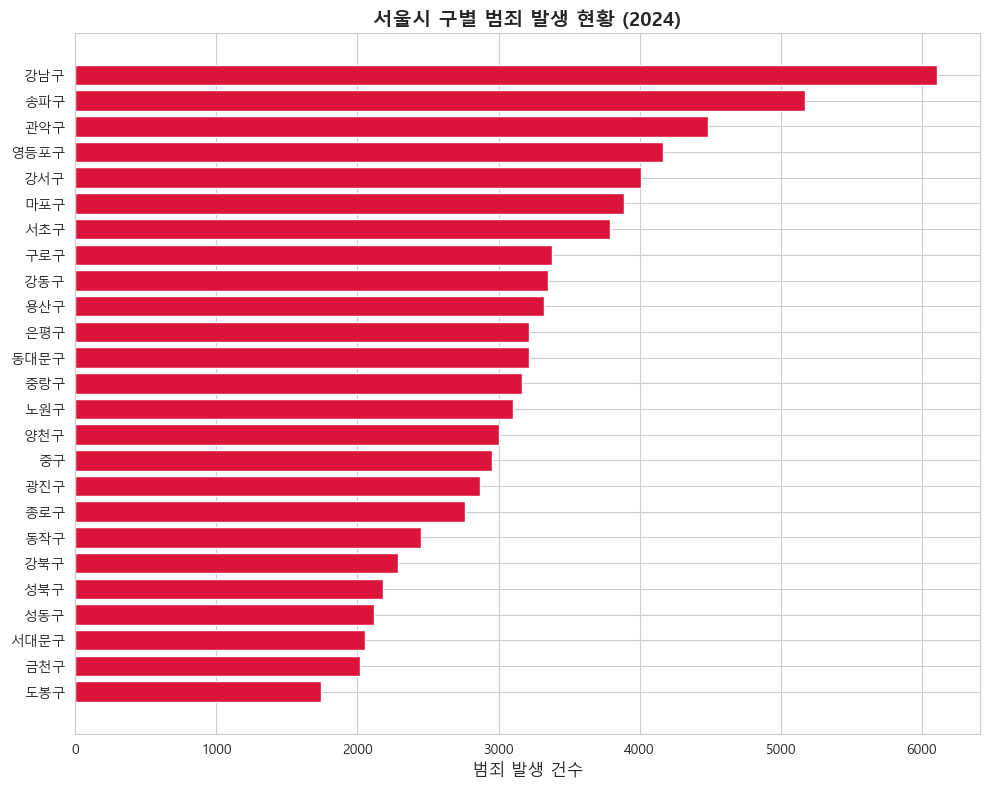


총 25개 지역
평균 범죄 발생: 3233건
최대: 6107건 (강남구)
최소: 1741건 (도봉구)


In [3]:
# 범죄 데이터 구조 확인 및 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib import font_manager, rc

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 범죄 데이터 로드
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황.csv', encoding='utf-8')

# 실제 데이터 추출 (4행부터)
crime_visual = crime_df.iloc[3:].copy()
crime_visual['region'] = crime_df.iloc[3:]['자치구별(2)'].values
crime_visual['crime_count'] = pd.to_numeric(crime_df.iloc[3:]['2024'].values, errors='coerce')
crime_visual = crime_visual[crime_visual['region'] != '소계'].copy()
crime_visual = crime_visual.dropna(subset=['crime_count'])

# 구별 범죄 발생 통계 그래프
plt.figure(figsize=(10, 8))

crime_sorted = crime_visual.sort_values('crime_count', ascending=False)
plt.barh(crime_sorted['region'], crime_sorted['crime_count'], color='crimson')
plt.xlabel('범죄 발생 건수', fontsize=12)
plt.title('서울시 구별 범죄 발생 현황 (2024)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# 통계 요약
print(f"\n총 {len(crime_visual)}개 지역")
print(f"평균 범죄 발생: {crime_visual['crime_count'].mean():.0f}건")
print(f"최대: {crime_visual['crime_count'].max():.0f}건 ({crime_visual.loc[crime_visual['crime_count'].idxmax(), 'region']})")
print(f"최소: {crime_visual['crime_count'].min():.0f}건 ({crime_visual.loc[crime_visual['crime_count'].idxmin(), 'region']})")


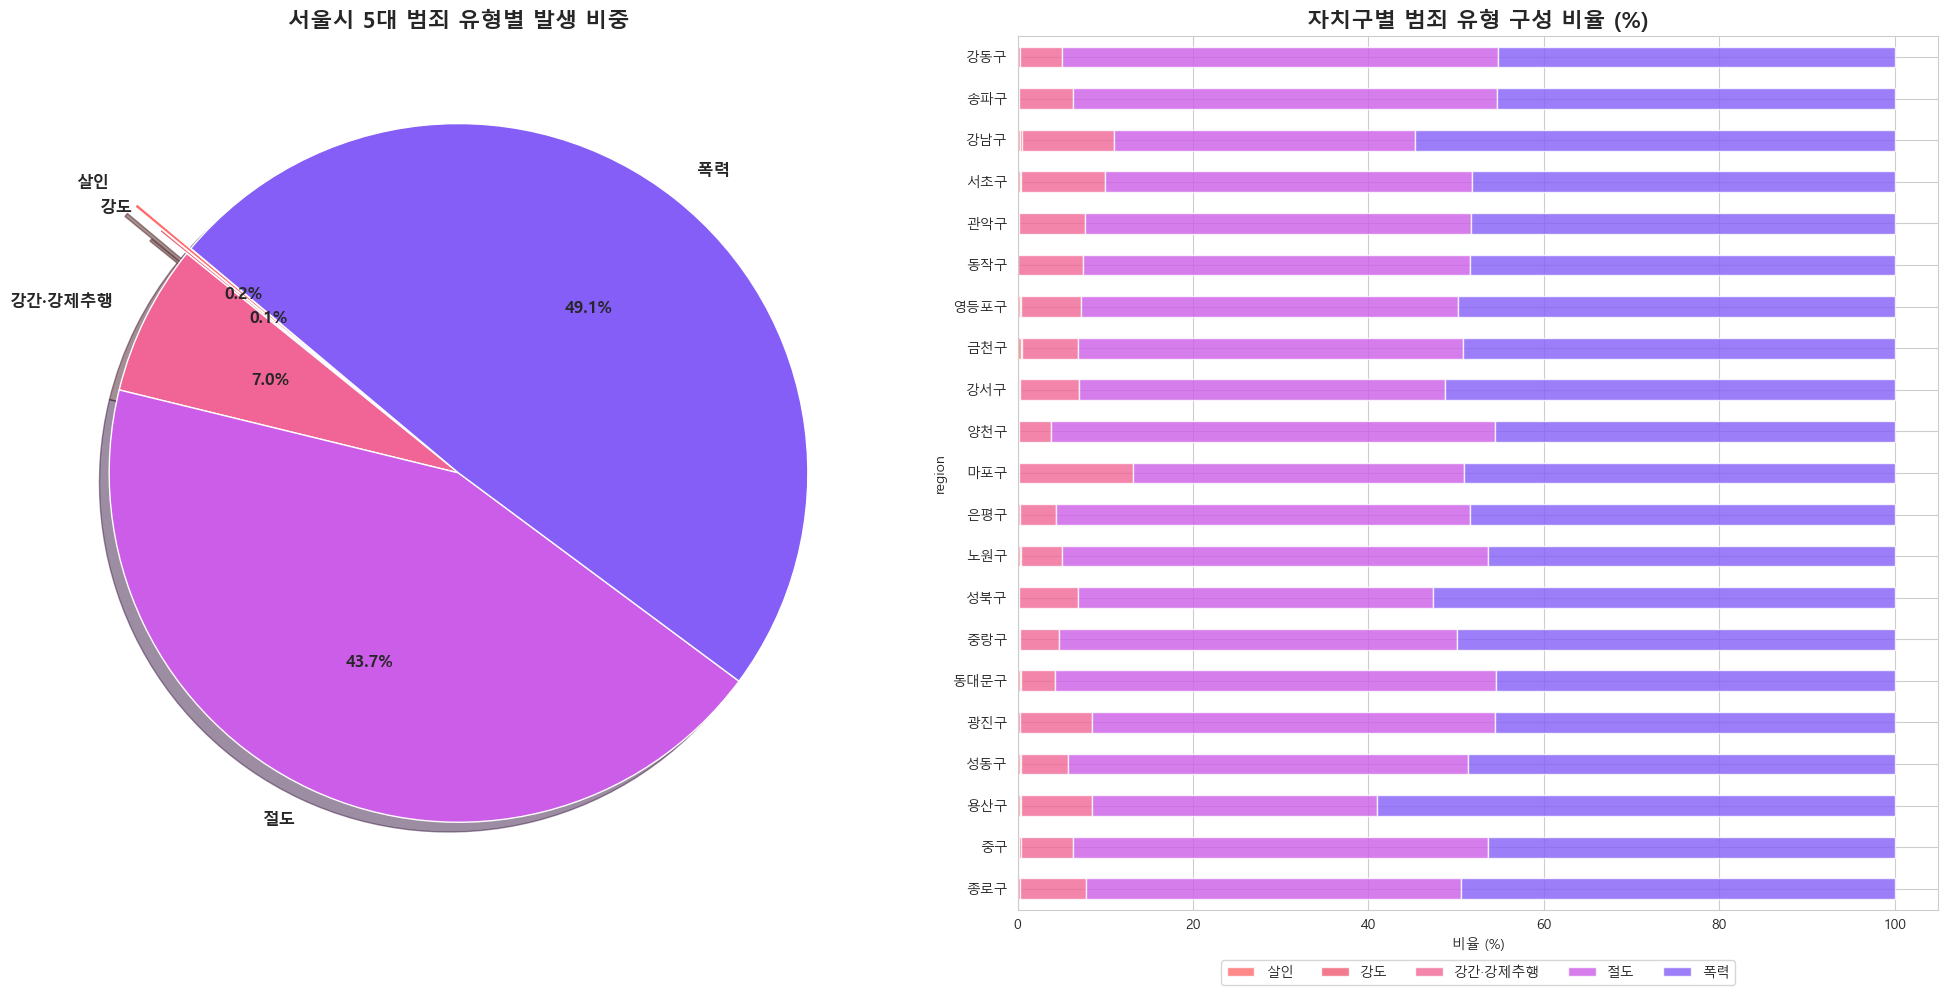

=== 서울시 범죄 유형별 발생 건수 및 비중 ===
살인:   126건 (  0.2%)
강도:    87건 (  0.1%)
강간·강제추행: 4,991건 (  7.0%)
절도: 31,150건 ( 43.7%)
폭력: 35,003건 ( 49.1%)


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 서울시 전체 범죄 유형별 합계 계산
crime_sum = {
    '살인': crime_detail['살인_발생'].sum(),
    '강도': crime_detail['강도_발생'].sum(),
    '강간·강제추행': crime_detail['강간강제추행_발생'].sum(),
    '절도': crime_detail['절도_발생'].sum(),
    '폭력': crime_detail['폭력_발생'].sum()
}
crime_ratio_df = pd.Series(crime_sum)

# 2. 시각화 (파이 차트 + 자치구별 누적 비율)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# [왼쪽] 전체 범죄 유형별 비율 (Pie Chart)
colors = ['#ff6b6b', '#ee5a6f', '#f06595', '#cc5de8', '#845ef7']
explode = [0.2, 0.1, 0, 0, 0] # 살인, 강도 강조

ax1.pie(crime_ratio_df, labels=crime_ratio_df.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=explode, shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('서울시 5대 범죄 유형별 발생 비중', fontsize=16, fontweight='bold')

# [오른쪽] 자치구별 범죄 유형 비중 (100% Stacked Bar)
# 각 구별로 총합을 100으로 맞춘 비율 데이터 생성
districts_crime = crime_detail[['region', '살인_발생', '강도_발생', '강간강제추행_발생', '절도_발생', '폭력_발생']].copy()
districts_crime.columns = ['region', '살인', '강도', '강간·강제추행', '절도', '폭력']
districts_crime.set_index('region', inplace=True)

# 비율(%)로 변환
districts_ratio = districts_crime.div(districts_crime.sum(axis=1), axis=0) * 100

districts_ratio.plot(kind='barh', stacked=True, ax=ax2, color=colors, alpha=0.8)
ax2.set_title('자치구별 범죄 유형 구성 비율 (%)', fontsize=16, fontweight='bold')
ax2.set_xlabel('비율 (%)')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)

plt.tight_layout()
plt.show()

# 3. 수치 요약 출력
print("=== 서울시 범죄 유형별 발생 건수 및 비중 ===")
total_cnt = crime_ratio_df.sum()
for crime, cnt in crime_sum.items():
    print(f"{crime}: {int(cnt):>5,}건 ({cnt/total_cnt*100:>5.1f}%)")

## 구별 범죄 발생 유형 분석 (발생 및 검거 비율)

분석 대상 지역: 21개
  region  살인_발생  살인_검거  강도_발생  강도_검거
1    종로구      2      3    5.0   10.0
2     중구      5      4    5.0    5.0
3    용산구     10      6    4.0    3.0
4    성동구      5      6    3.0    3.0
5    광진구      2      2    6.0    7.0


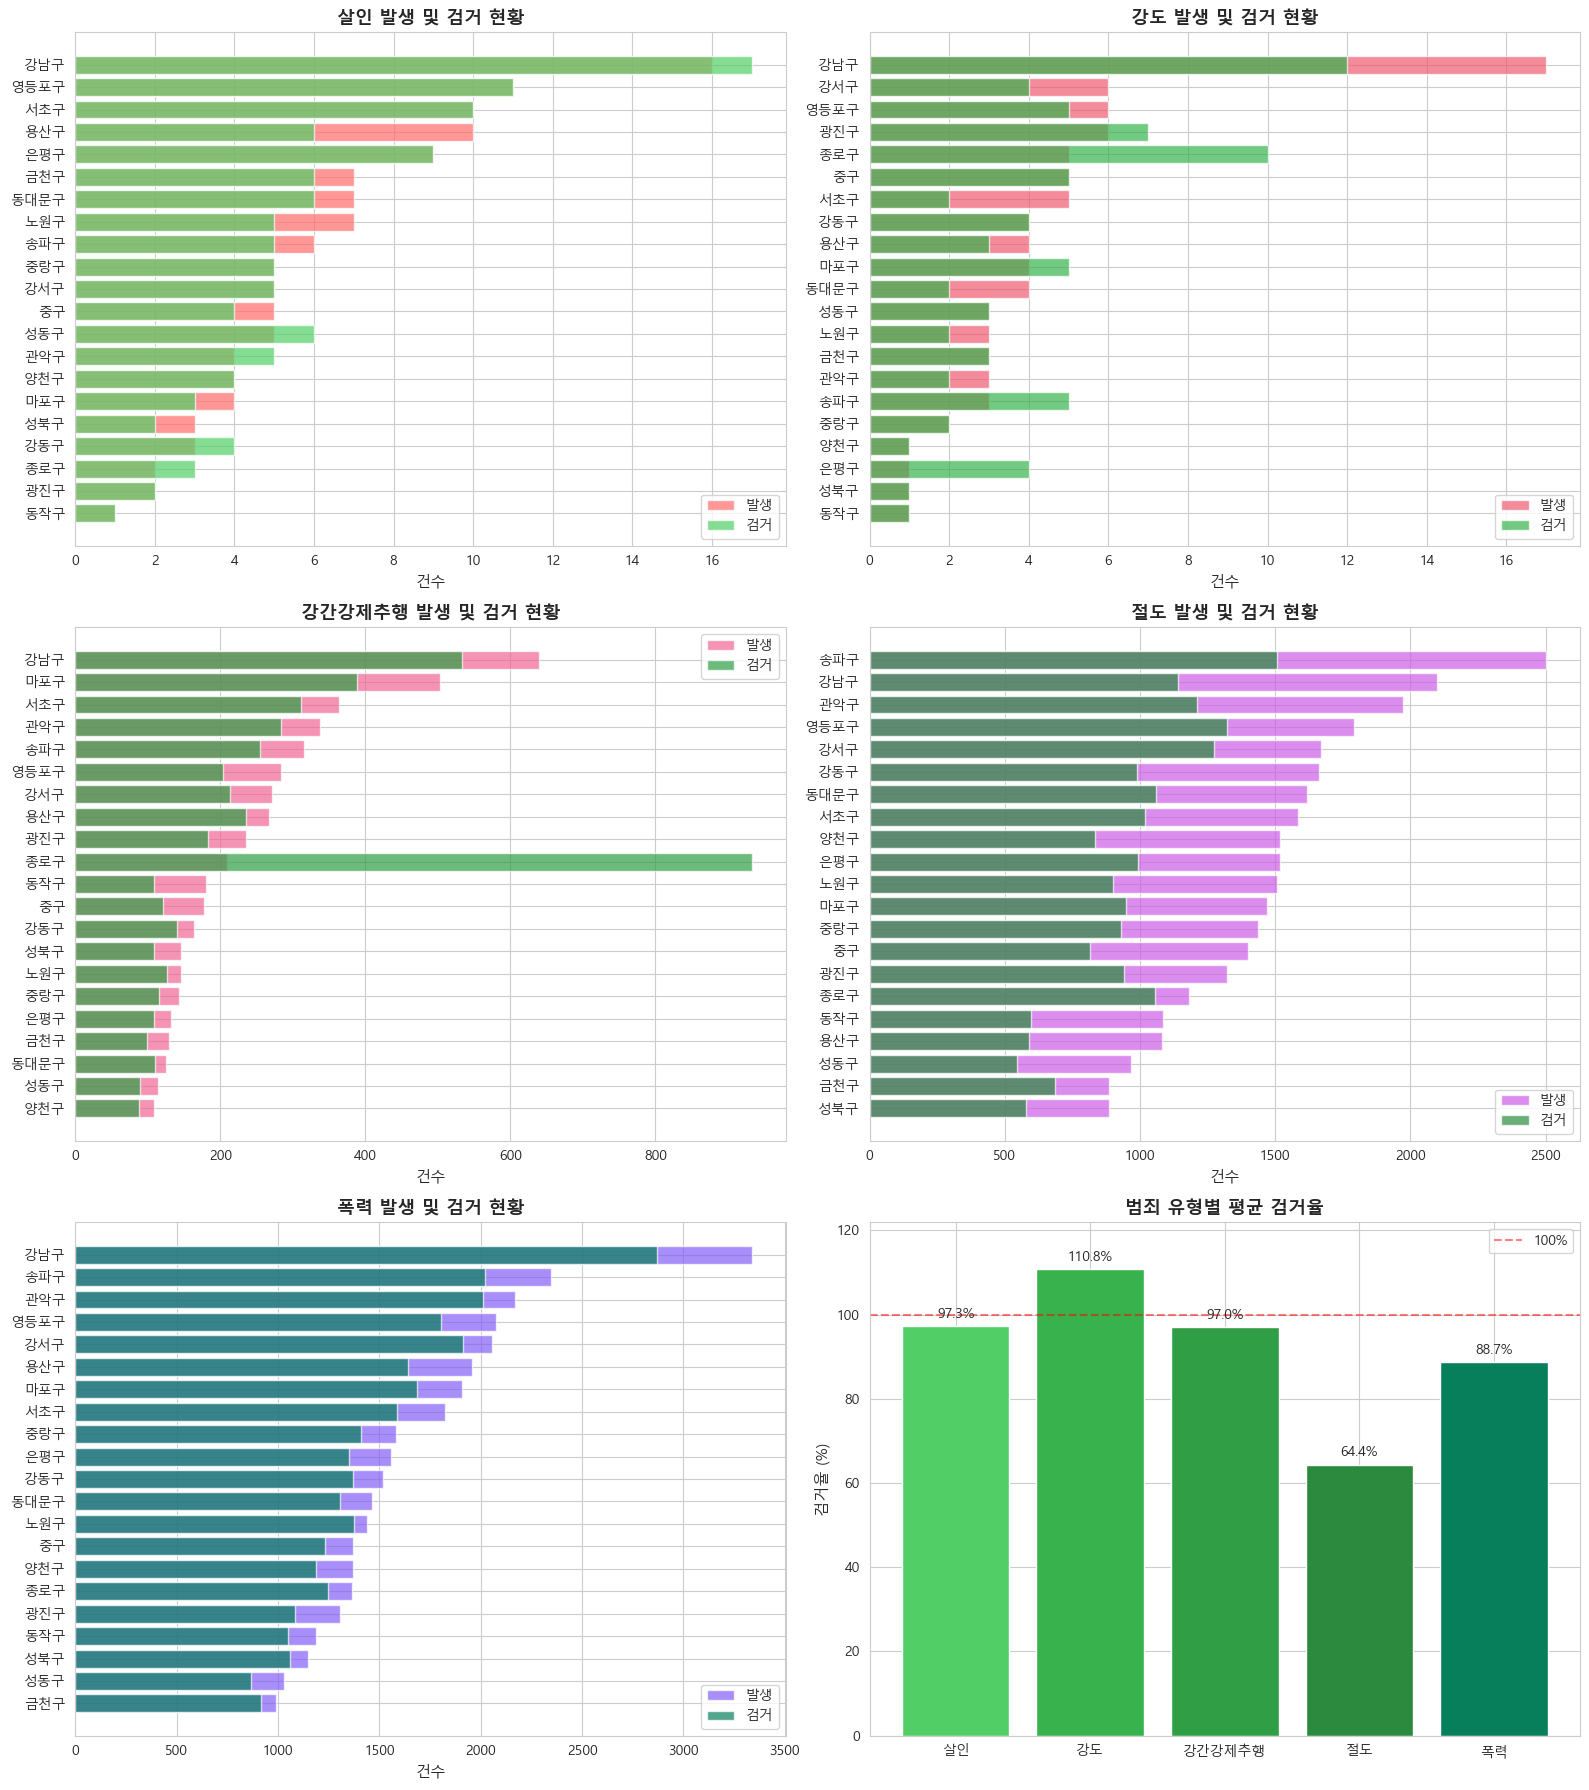


=== 범죄 유형별 통계 ===

살인:
  총 발생: 126건
  총 검거: 119건
  검거율: 94.4%

강도:
  총 발생: 87건
  총 검거: 83건
  검거율: 95.4%

강간강제추행:
  총 발생: 4991건
  총 검거: 4758건
  검거율: 95.3%

절도:
  총 발생: 31150건
  총 검거: 19935건
  검거율: 64.0%

폭력:
  총 발생: 35003건
  총 검거: 30991건
  검거율: 88.5%


In [4]:
# 범죄 유형별 발생 및 검거 비율 분석
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 범죄 데이터 로드
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황.csv', encoding='utf-8')

# 실제 데이터 추출 (4행부터, index=3부터)
crime_detail = crime_df.iloc[3:].reset_index(drop=True).copy()

# 지역명 추출
crime_detail['region'] = crime_detail['자치구별(2)']
crime_detail = crime_detail[crime_detail['region'] != '소계'].copy()

# 각 범죄 유형별 발생/검거 데이터 추출
crime_detail['살인_발생'] = pd.to_numeric(crime_detail['2024.2'], errors='coerce')
crime_detail['살인_검거'] = pd.to_numeric(crime_detail['2024.3'], errors='coerce')
crime_detail['강도_발생'] = pd.to_numeric(crime_detail['2024.4'], errors='coerce')
crime_detail['강도_검거'] = pd.to_numeric(crime_detail['2024.5'], errors='coerce')
crime_detail['강간강제추행_발생'] = pd.to_numeric(crime_detail['2024.6'], errors='coerce')
crime_detail['강간강제추행_검거'] = pd.to_numeric(crime_detail['2024.7'], errors='coerce')
crime_detail['절도_발생'] = pd.to_numeric(crime_detail['2024.8'], errors='coerce')
crime_detail['절도_검거'] = pd.to_numeric(crime_detail['2024.9'], errors='coerce')
crime_detail['폭력_발생'] = pd.to_numeric(crime_detail['2024.10'], errors='coerce')
crime_detail['폭력_검거'] = pd.to_numeric(crime_detail['2024.11'], errors='coerce')

crime_detail = crime_detail.dropna()

# 검거율 계산
crime_detail['살인_검거율'] = (crime_detail['살인_검거'] / crime_detail['살인_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
crime_detail['강도_검거율'] = (crime_detail['강도_검거'] / crime_detail['강도_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
crime_detail['강간강제추행_검거율'] = (crime_detail['강간강제추행_검거'] / crime_detail['강간강제추행_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
crime_detail['절도_검거율'] = (crime_detail['절도_검거'] / crime_detail['절도_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
crime_detail['폭력_검거율'] = (crime_detail['폭력_검거'] / crime_detail['폭력_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)

print(f"분석 대상 지역: {len(crime_detail)}개")
print(crime_detail[['region', '살인_발생', '살인_검거', '강도_발생', '강도_검거']].head())

# 시각화
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

crime_types = ['살인', '강도', '강간강제추행', '절도', '폭력']
colors_occur = ['#ff6b6b', '#ee5a6f', '#f06595', '#cc5de8', '#845ef7']
colors_arrest = ['#51cf66', '#37b24d', '#2f9e44', '#2b8a3e', '#087f5b']

for idx, crime_type in enumerate(crime_types):
    row = idx // 2
    col = idx % 2
    
    # 발생 건수로 정렬
    crime_sorted = crime_detail.sort_values(f'{crime_type}_발생', ascending=False)
    
    axes[row, col].barh(crime_sorted['region'], crime_sorted[f'{crime_type}_발생'], 
                        color=colors_occur[idx], alpha=0.7, label='발생')
    axes[row, col].barh(crime_sorted['region'], crime_sorted[f'{crime_type}_검거'], 
                        color=colors_arrest[idx], alpha=0.7, label='검거')
    
    axes[row, col].set_xlabel('건수', fontsize=11)
    axes[row, col].set_title(f'{crime_type} 발생 및 검거 현황', fontsize=13, fontweight='bold')
    axes[row, col].legend()
    axes[row, col].invert_yaxis()

# 검거율 비교
axes[2, 1].clear()
avg_arrest_rates = {
    '살인': crime_detail['살인_검거율'].mean(),
    '강도': crime_detail['강도_검거율'].mean(),
    '강간강제추행': crime_detail['강간강제추행_검거율'].mean(),
    '절도': crime_detail['절도_검거율'].mean(),
    '폭력': crime_detail['폭력_검거율'].mean()
}

axes[2, 1].bar(avg_arrest_rates.keys(), avg_arrest_rates.values(), 
               color=['#51cf66', '#37b24d', '#2f9e44', '#2b8a3e', '#087f5b'])
axes[2, 1].set_ylabel('검거율 (%)', fontsize=11)
axes[2, 1].set_title('범죄 유형별 평균 검거율', fontsize=13, fontweight='bold')
axes[2, 1].axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100%')
axes[2, 1].legend()
axes[2, 1].set_ylim(0, max(avg_arrest_rates.values()) * 1.1)

# 값 표시
for i, (crime, rate) in enumerate(avg_arrest_rates.items()):
    axes[2, 1].text(i, rate + 2, f'{rate:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 범죄 유형별 통계 ===")
for crime_type in crime_types:
    total_occur = crime_detail[f'{crime_type}_발생'].sum()
    total_arrest = crime_detail[f'{crime_type}_검거'].sum()
    arrest_rate = (total_arrest / total_occur * 100) if total_occur > 0 else 0
    print(f"\n{crime_type}:")
    print(f"  총 발생: {total_occur:.0f}건")
    print(f"  총 검거: {total_arrest:.0f}건")
    print(f"  검거율: {arrest_rate:.1f}%")

# CCTV 현황 분석

In [5]:
# 1.2 CCTV 정보
cctv_df = pd.read_excel('../data/GraphDB_data/safety/12_04_08_E_CCTV정보.xlsx')
print(f"✓ CCTV 정보: {cctv_df.shape}")
cctv_df.head()

c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


✓ CCTV 정보: (57699, 14)


,번호,관리기관명,소재지도로명주소,소재지지번주소,설치목적구분,카메라대수,카메라화소수,촬영방면정보,보관일수,설치연월,관리기관전화번호,WGS84위도,WGS84경도,데이터기준일자
0,1,서울특별시 성동구청,서울특별시 마조로 11,서울특별시 행당동 19-98,교통단속,3,200,360도전방면,30,2013-11,02-2286-5878,37.558960,127.040794,2022-06-24
1,2,서울특별시 성동구청,서울특별시 고산자로 330 (마장동),서울특별시 마장동 520-10,교통단속,2,200,360도전방면,30,2013-11,02-2286-5878,37.569137,127.037521,2022-06-24
2,3,서울특별시 성동구청,서울특별시 마장로35길 76,서울특별시 마장동 818,교통단속,3,200,360도전방면,30,2013-11,02-2286-5878,37.570602,127.042519,2022-06-24
3,4,서울특별시 성동구청,서울특별시 마장로 325 (마장동),서울특별시 마장동 767-41,교통단속,3,200,360도전방면,30,2017-11,02-2286-5878,37.567585,127.044815,2022-06-24
4,5,서울특별시 성동구청,서울특별시 마장로 322 (마장동),서울특별시 마장동 781-1,교통단속,2,200,360도전방면,30,2017-11,02-2286-5878,37.566624,127.043945,2022-06-24


## CCTV 설치 목적

In [6]:
# CCTV 설치목적구분 확인
print("=== CCTV 설치목적구분 ===")
print(cctv_df['설치목적구분'].value_counts())

print("\n=== 설치목적구분 종류 ===")
print(cctv_df['설치목적구분'].unique())

print(f"\n총 {cctv_df['설치목적구분'].nunique()}개 유형")

=== CCTV 설치목적구분 ===
설치목적구분
생활방범      37244
다목적        5532
교통단속       5105
어린이보호      3739
시설물관리      1803
기타         1628
재난재해       1240
쓰레기단속      1234
차량방범        153
교통정보수집       21
Name: count, dtype: int64

=== 설치목적구분 종류 ===
['교통단속' '쓰레기단속' '생활방범' '차량방범' '시설물관리' '다목적' '재난재해' '기타' '어린이보호' '교통정보수집']

총 10개 유형


In [7]:
# 구별 
# "서울특별시", "서울시", 또는 아무것도 없는 경우 모두 처리
cctv_df['region'] = cctv_df['관리기관명'].str.extract(r'(?:서울특별시|서울시)?\s*(\S+구)')

# 확인
print(f"총 구 개수: {cctv_df['region'].nunique()}개")
print("\n구별 개수:")
print(cctv_df['region'].value_counts().sort_index())

# 다시 집계
cctv_pivot = cctv_df.groupby(['region', '설치목적구분']).size().unstack(fill_value=0)

# 안전 관련 CCTV만 따로 집계
safety_purposes = ['생활방범', '어린이보호']
cctv_pivot['안전CCTV합계'] = cctv_pivot[safety_purposes].sum(axis=1)

print("\n=== 구별 안전 관련 CCTV 합계 ===")
print(cctv_pivot[['생활방범', '어린이보호', '안전CCTV합계']].sort_values('안전CCTV합계', ascending=False))

# 25개 구 모두 있는지 확인
seoul_districts = [
    '강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구',
    '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구',
    '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구',
    '종로구', '중구', '중랑구'
]

extracted = set(cctv_df['region'].dropna().unique())
missing = set(seoul_districts) - extracted

if missing:
    print(f"\n아직 누락된 구: {missing}")
else:
    print("\n✓ 25개 구 모두 추출 완료!")


총 구 개수: 25개

구별 개수:
region
강남구     2578
강동구     1461
강북구     4360
강서구     1964
관악구     2040
광진구     1304
구로구     2132
금천구      935
노원구     3111
도봉구     2807
동대문구    1324
동작구      890
마포구     1497
서대문구    1292
서초구     6324
성동구     1314
성북구     2366
송파구     1829
양천구     4795
영등포구    5300
용산구     1930
은평구     1773
종로구     1224
중구      1156
중랑구     1993
Name: count, dtype: int64

=== 구별 안전 관련 CCTV 합계 ===
설치목적구분  생활방범  어린이보호  안전CCTV합계
region                       
양천구     3432    910      4342
강북구     3844    356      4200
서초구     3903    200      4103
도봉구     2429    196      2625
강남구     2010      0      2010
노원구     1625    302      1927
중랑구     1679    122      1801
강서구     1674    126      1800
구로구     1495    229      1724
용산구     1493    118      1611
송파구     1304    192      1496
성북구     1331    164      1495
은평구     1389      0      1389
강동구     1216    143      1359
마포구     1349      0      1349
동대문구    1194      0      1194
광진구      940    148      1088
종로구     1016      0      1

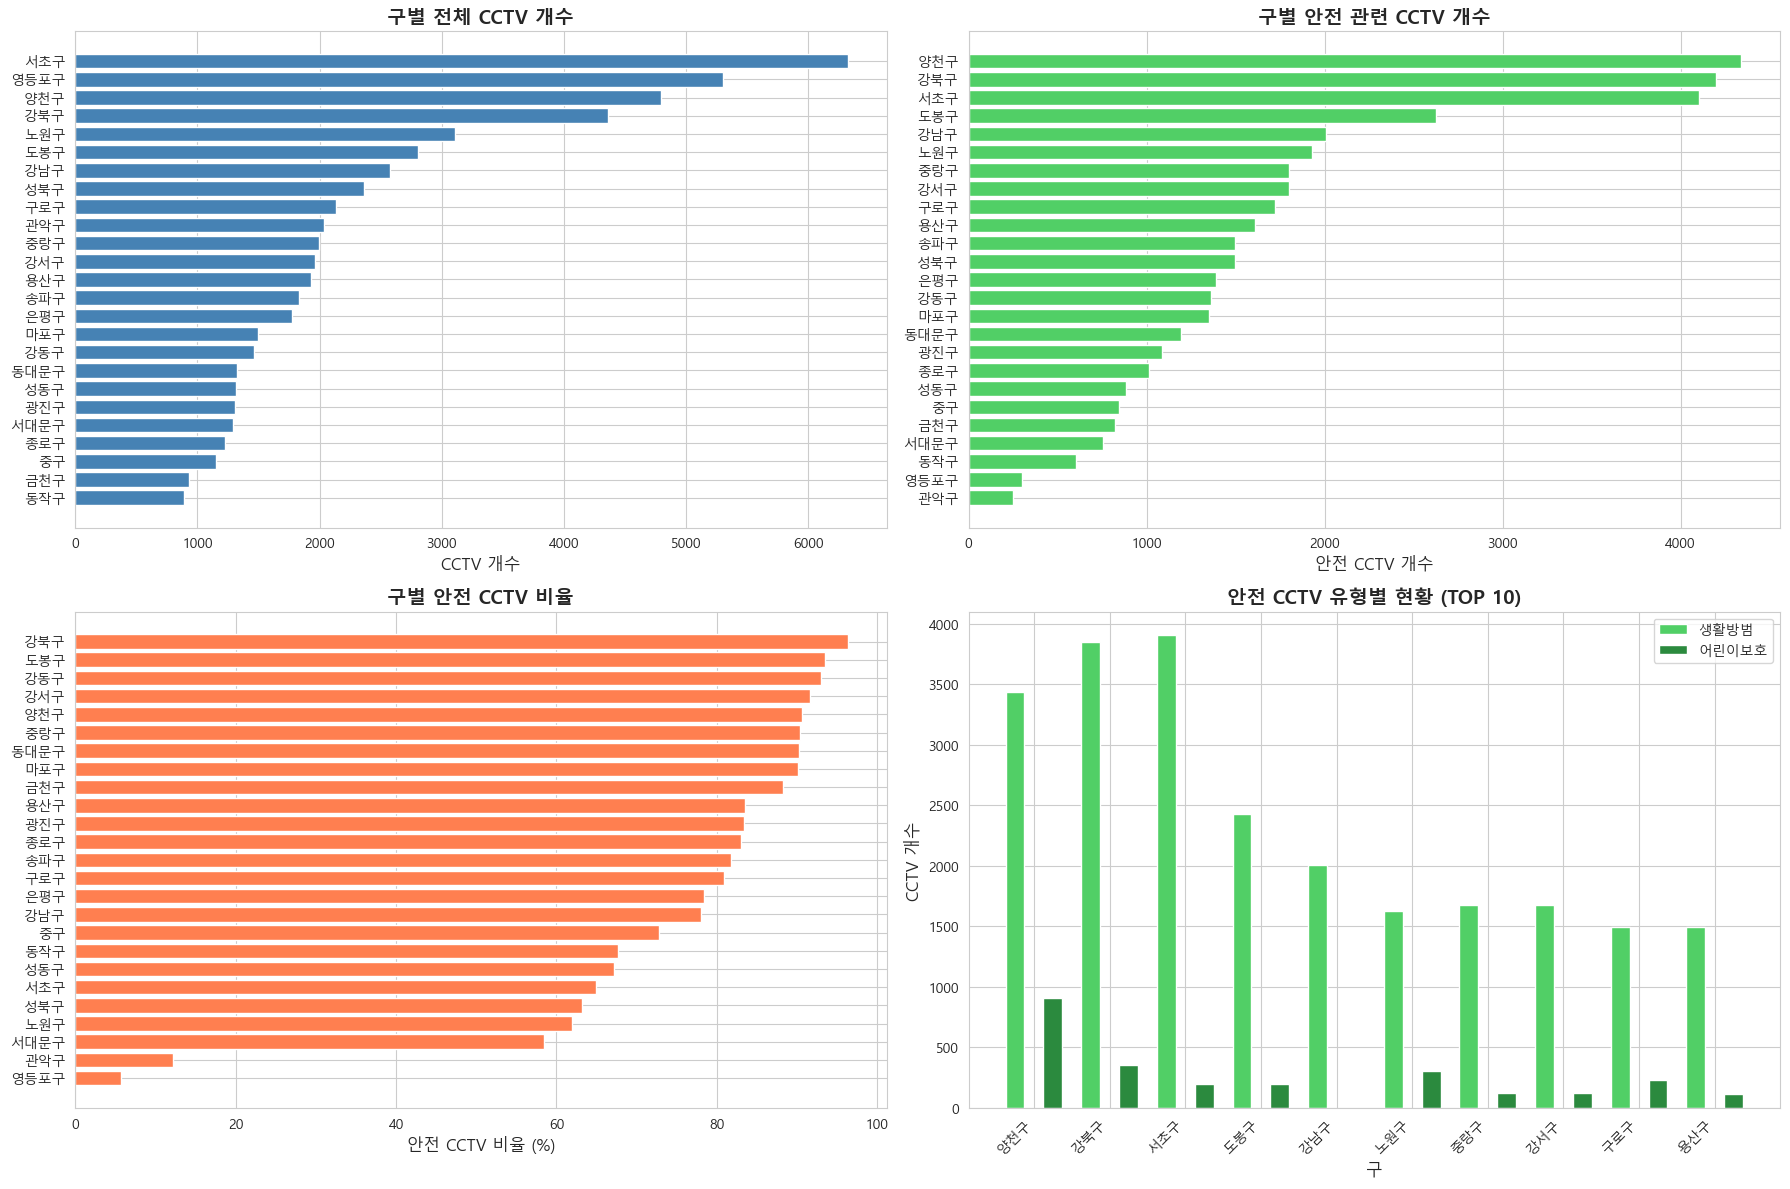


=== CCTV 통계 요약 ===
전체 CCTV: 57,699대
안전 CCTV: 40,983대 (71.0%)

평균 (구당):
  전체 CCTV: 2308대
  안전 CCTV: 1639대

최대:
  전체 CCTV: 6324대 (서초구)
  안전 CCTV: 4342대 (양천구)

최소:
  전체 CCTV: 890대 (동작구)
  안전 CCTV: 248대 (관악구)


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 전체 CCTV 개수 (단순 막대그래프)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1-1. 전체 CCTV 개수
total_cctv = cctv_df.groupby('region').size().sort_values(ascending=False)
axes[0, 0].barh(total_cctv.index, total_cctv.values, color='steelblue')
axes[0, 0].set_xlabel('CCTV 개수', fontsize=12)
axes[0, 0].set_title('구별 전체 CCTV 개수', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()

# 1-2. 안전 CCTV 개수
safety_cctv = cctv_pivot['안전CCTV합계'].sort_values(ascending=False)
axes[0, 1].barh(safety_cctv.index, safety_cctv.values, color='#51cf66')
axes[0, 1].set_xlabel('안전 CCTV 개수', fontsize=12)
axes[0, 1].set_title('구별 안전 관련 CCTV 개수', fontsize=14, fontweight='bold')
axes[0, 1].invert_yaxis()

# 1-3. 안전 CCTV 비율
cctv_total_by_region = cctv_df.groupby('region').size()
safety_ratio = (cctv_pivot['안전CCTV합계'] / cctv_total_by_region * 100).sort_values(ascending=False)
axes[1, 0].barh(safety_ratio.index, safety_ratio.values, color='coral')
axes[1, 0].set_xlabel('안전 CCTV 비율 (%)', fontsize=12)
axes[1, 0].set_title('구별 안전 CCTV 비율', fontsize=14, fontweight='bold')
axes[1, 0].invert_yaxis()

# 1-4. 안전 CCTV 유형별 (상위 10개 구)
top10_regions = cctv_pivot['안전CCTV합계'].nlargest(10).index
top10_data = cctv_pivot.loc[top10_regions, ['생활방범', '어린이보호']]

x = np.arange(len(top10_regions))
width = 0.25

axes[1, 1].bar(x - width, top10_data['생활방범'], width, label='생활방범', color='#51cf66')
axes[1, 1].bar(x + width, top10_data['어린이보호'], width, label='어린이보호', color='#2b8a3e')

axes[1, 1].set_xlabel('구', fontsize=12)
axes[1, 1].set_ylabel('CCTV 개수', fontsize=12)
axes[1, 1].set_title('안전 CCTV 유형별 현황 (TOP 10)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(top10_regions, rotation=45, ha='right')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== CCTV 통계 요약 ===")
print(f"전체 CCTV: {len(cctv_df):,}대")
print(f"안전 CCTV: {cctv_pivot['안전CCTV합계'].sum():,.0f}대 ({cctv_pivot['안전CCTV합계'].sum()/len(cctv_df)*100:.1f}%)")
print(f"\n평균 (구당):")
print(f"  전체 CCTV: {cctv_total_by_region.mean():.0f}대")
print(f"  안전 CCTV: {cctv_pivot['안전CCTV합계'].mean():.0f}대")
print(f"\n최대:")
print(f"  전체 CCTV: {cctv_total_by_region.max():.0f}대 ({cctv_total_by_region.idxmax()})")
print(f"  안전 CCTV: {cctv_pivot['안전CCTV합계'].max():.0f}대 ({cctv_pivot['안전CCTV합계'].idxmax()})")
print(f"\n최소:")
print(f"  전체 CCTV: {cctv_total_by_region.min():.0f}대 ({cctv_total_by_region.idxmin()})")
print(f"  안전 CCTV: {cctv_pivot['안전CCTV합계'].min():.0f}대 ({cctv_pivot['안전CCTV합계'].idxmin()})")


# 지구대/파출소 정보

In [9]:
# 1.3 지구대/파출소 정보
try:
    police_df = pd.read_csv('../data/GraphDB_data/office/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='utf-8')
except UnicodeDecodeError:
    try:
        police_df = pd.read_csv('../data/GraphDB_data/office/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='cp949')
    except UnicodeDecodeError:
        police_df = pd.read_csv('../data/GraphDB_data/office/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='euc-kr')
        
print(f"✓ 지구대/파출소 정보: {police_df.shape}")
police_df.head()

✓ 지구대/파출소 정보: (2045, 9)


,연번,시도청,경찰서,관서명,구분,전화번호,주소,위도,경도
0,1,서울청,서울중부,을지,지구대,02-2279-1908,서울특별시 중구 퇴계로49길 13,37.563061,127.000149
1,2,서울청,서울중부,광희,지구대,02-2233-1444,서울특별시 중구 퇴계로 375-1,37.565268,127.013376
2,3,서울청,서울중부,약수,지구대,02-2234-8112,서울특별시 중구 동호로 5길 15,37.552144,127.012382
3,4,서울청,서울중부,신당,파출소,02-2252-0435,"서울특별시 중구 다산로 248 (신당동, 신당파출소)",37.565044,127.016385
4,5,서울청,서울중부,장충,파출소,02-2274-9003,서울특별시 중구 동호로 261,37.558763,127.004802


총 구 개수: 25개

구별 지구대/파출소 수:
   region  police_count
22    종로구            20
23     중구            15
0     강남구            14
3     강서구            11
10   동대문구            11
14    서초구            11
17    송파구            11
19   영등포구            10
5     광진구            10
16    성북구            10
2     강북구             9
21    은평구             9
4     관악구             9
1     강동구             9
15    성동구             9
6     구로구             8
8     노원구             8
24    중랑구             8
13   서대문구             8
12    마포구             8
9     도봉구             8
18    양천구             8
11    동작구             7
20    용산구             7
7     금천구             5


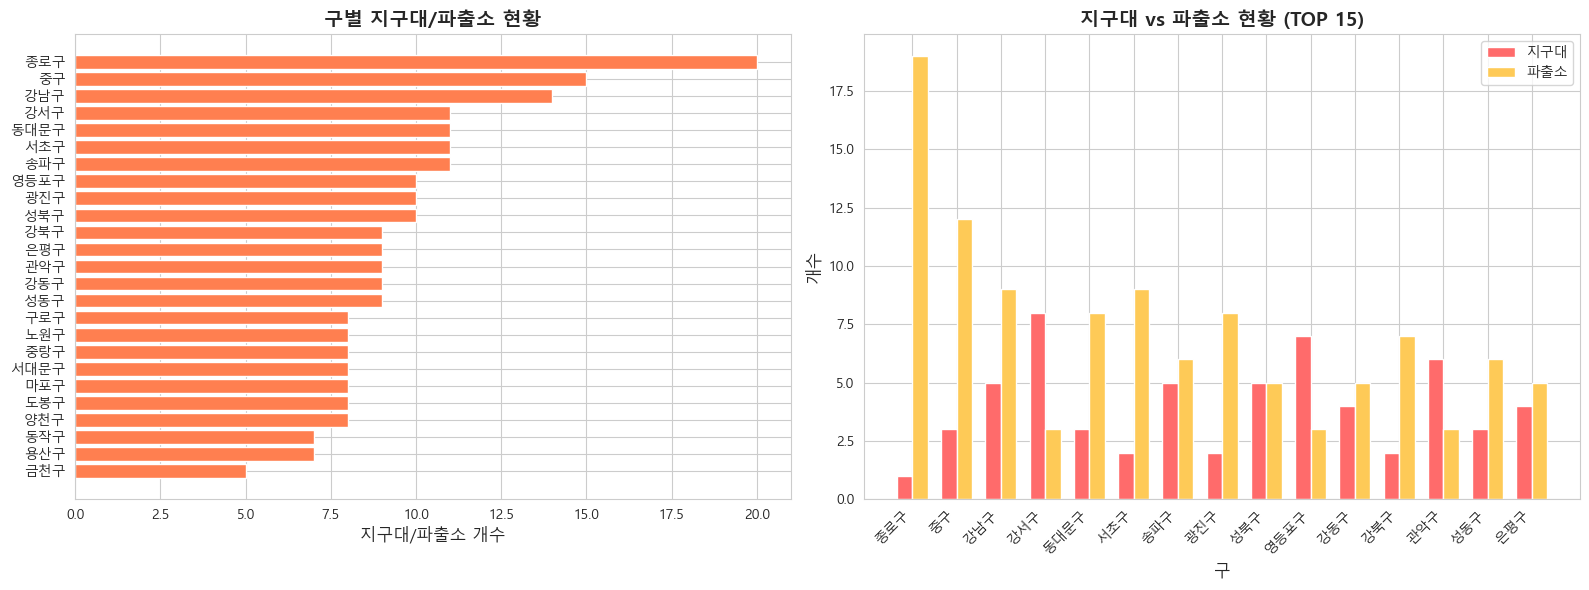


=== 지구대/파출소 통계 ===
총 개수: 243개
평균 (구당): 9.7개
최대: 20개 (종로구)
최소: 5개 (금천구)

구분별:
구분
파출소    144
지구대     99
Name: count, dtype: int64


In [10]:
# 지구대/파출소 구별 집계
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 서울시만 필터링
seoul_police = police_df[police_df['시도청'] == '서울청'].copy()

# 주소에서 구 이름 추출
seoul_police['region'] = seoul_police['주소'].str.extract(r'(?:서울특별시|서울시)?\s*(\S+구)')

# 구별 집계
police_by_region = seoul_police.groupby('region').size().reset_index(name='police_count')

print(f"총 구 개수: {len(police_by_region)}개")
print("\n구별 지구대/파출소 수:")
print(police_by_region.sort_values('police_count', ascending=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 전체 구
police_sorted = police_by_region.sort_values('police_count', ascending=False)
axes[0].barh(police_sorted['region'], police_sorted['police_count'], color='coral')
axes[0].set_xlabel('지구대/파출소 개수', fontsize=12)
axes[0].set_title('구별 지구대/파출소 현황', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# 구분별 (지구대 vs 파출소)
seoul_police['구분_count'] = 1
police_type = seoul_police.groupby(['region', '구분']).size().unstack(fill_value=0)

# 상위 15개 구
top15 = police_by_region.nlargest(15, 'police_count')['region']
police_type_top15 = police_type.loc[top15]

x = range(len(police_type_top15))
width = 0.35

if '지구대' in police_type_top15.columns:
    axes[1].bar([i - width/2 for i in x], police_type_top15['지구대'], width, label='지구대', color='#ff6b6b')
if '파출소' in police_type_top15.columns:
    axes[1].bar([i + width/2 for i in x], police_type_top15['파출소'], width, label='파출소', color='#feca57')

axes[1].set_xlabel('구', fontsize=12)
axes[1].set_ylabel('개수', fontsize=12)
axes[1].set_title('지구대 vs 파출소 현황 (TOP 15)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(police_type_top15.index, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 지구대/파출소 통계 ===")
print(f"총 개수: {len(seoul_police)}개")
print(f"평균 (구당): {police_by_region['police_count'].mean():.1f}개")
print(f"최대: {police_by_region['police_count'].max()}개 ({police_by_region.loc[police_by_region['police_count'].idxmax(), 'region']})")
print(f"최소: {police_by_region['police_count'].min()}개 ({police_by_region.loc[police_by_region['police_count'].idxmin(), 'region']})")

if '구분' in seoul_police.columns:
    print(f"\n구분별:")
    print(seoul_police['구분'].value_counts())


# 소방서 정보

In [11]:
# 1.4 소방서 정보
try:
    fire_df = pd.read_csv('../data/GraphDB_data/office/소방청_시도 소방서 현황_20250701.csv', encoding='utf-8')
except UnicodeDecodeError:
    try:
        fire_df = pd.read_csv('../data/GraphDB_data/office/소방청_시도 소방서 현황_20250701.csv', encoding='cp949')
    except UnicodeDecodeError:
        fire_df = pd.read_csv('../data/GraphDB_data/office/소방청_시도 소방서 현황_20250701.csv', encoding='euc-kr')
        
print(f"✓ 소방서 정보: {fire_df.shape}")
fire_df.head()

✓ 소방서 정보: (242, 8)


,순번,소방본부,소방서,주소,전화번호,팩스번호,위도,경도
0,1,서울특별시,강남소방서,서울특별시 강남구 테헤란로 629 (삼성동),02-6981-7408,02-2187-8220,37.510279,127.066830
1,2,서울특별시,강동소방서,서울특별시 강동구 성내로 39 (성내동),02-6981-7673,02-6981-7717,37.529458,127.125372
2,3,서울특별시,강북소방서,서울특별시 강북구 한천로 911 (번동),02-6946-0119,02-6946-0183,37.633051,127.038181
3,4,서울특별시,강서소방서,서울특별시 강서구 양천로 550 (등촌동),02-6981-5000,02-2187-8243,37.558246,126.860047
4,5,서울특별시,관악소방서,서울특별시 관악구 관악로 97 (봉천동),02-6981-8200,02-2187-8300,37.474125,126.952685


총 구 개수: 25개

구별 소방서 수:
   region  fire_count
0     강남구           1
1     강동구           1
2     강북구           1
3     강서구           1
4     관악구           1
5     광진구           1
6     구로구           1
7     금천구           1
8     노원구           1
9     도봉구           1
10   동대문구           1
11    동작구           1
12    마포구           1
13   서대문구           1
14    서초구           1
15    성동구           1
16    성북구           1
17    송파구           1
18    양천구           1
19   영등포구           1
20    용산구           1
21    은평구           1
22    종로구           1
23     중구           1
24    중랑구           1


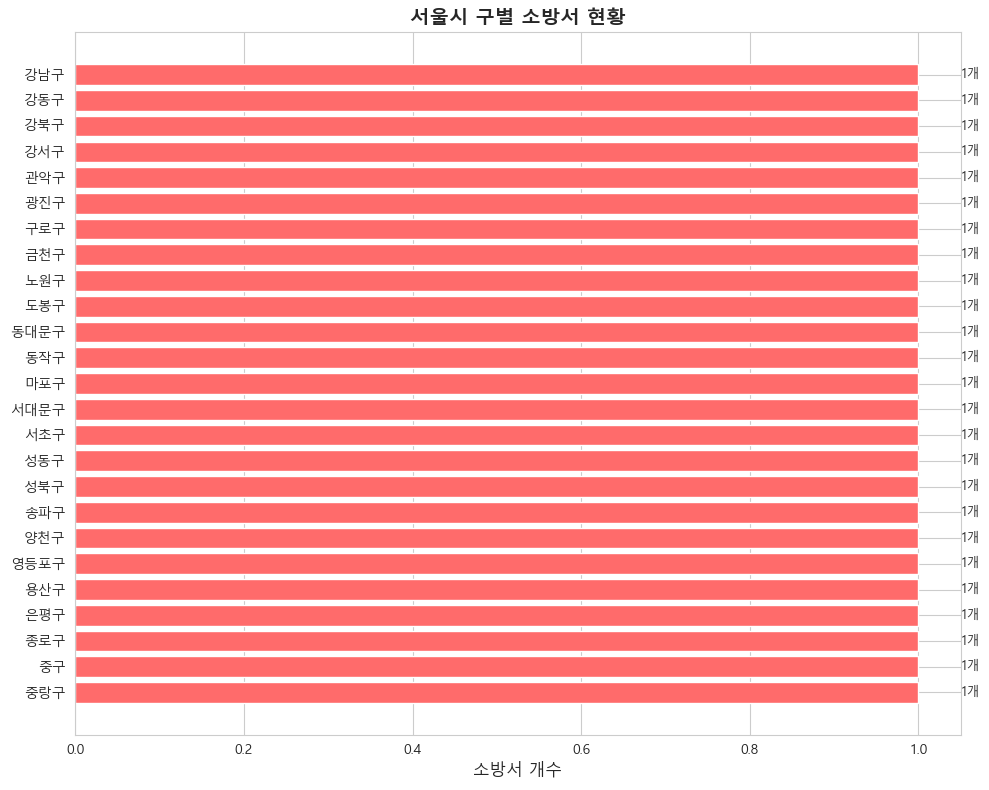


=== 소방서 통계 ===
총 개수: 25개
평균 (구당): 1.0개
최대: 1개 (강남구)
최소: 1개 (강남구)

서울시 소방서 목록:
소방서
강남소방서     1
강동소방서     1
강북소방서     1
강서소방서     1
관악소방서     1
광진소방서     1
구로소방서     1
금천소방서     1
노원소방서     1
도봉소방서     1
동대문소방서    1
동작소방서     1
마포소방서     1
서대문소방서    1
서초소방서     1
성동소방서     1
성북소방서     1
송파소방서     1
양천소방서     1
영등포소방서    1
용산소방서     1
은평소방서     1
종로소방서     1
중랑소방서     1
중부소방서     1
Name: count, dtype: int64


In [12]:
# 소방서 구별 집계
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 서울시만 필터링
seoul_fire = fire_df[fire_df['소방본부'] == '서울특별시'].copy()

# 주소에서 구 이름 추출
seoul_fire['region'] = seoul_fire['주소'].str.extract(r'(?:서울특별시|서울시)?\s*(\S+구)')

# 구별 집계
fire_by_region = seoul_fire.groupby('region').size().reset_index(name='fire_count')

print(f"총 구 개수: {len(fire_by_region)}개")
print("\n구별 소방서 수:")
print(fire_by_region.sort_values('fire_count', ascending=False))

# 시각화
plt.figure(figsize=(10, 8))

fire_sorted = fire_by_region.sort_values('fire_count', ascending=False)
plt.barh(fire_sorted['region'], fire_sorted['fire_count'], color='#ff6b6b')
plt.xlabel('소방서 개수', fontsize=12)
plt.title('서울시 구별 소방서 현황', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# 값 표시
for idx, row in fire_sorted.iterrows():
    plt.text(row['fire_count'] + 0.05, row['region'], f"{int(row['fire_count'])}개", 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 소방서 통계 ===")
print(f"총 개수: {len(seoul_fire)}개")
print(f"평균 (구당): {fire_by_region['fire_count'].mean():.1f}개")
print(f"최대: {fire_by_region['fire_count'].max()}개 ({fire_by_region.loc[fire_by_region['fire_count'].idxmax(), 'region']})")
print(f"최소: {fire_by_region['fire_count'].min()}개 ({fire_by_region.loc[fire_by_region['fire_count'].idxmin(), 'region']})")

# 소방서명 확인
print("\n서울시 소방서 목록:")
print(seoul_fire['소방서'].value_counts())


# 안전 비상벨 정보

In [13]:
# 1.5 안전비상벨 정보
bell_df = pd.read_excel('../data/GraphDB_data/safety/12_04_09_E_안전비상벨위치정보.xlsx')
print(f"✓ 안전비상벨 정보: {bell_df.shape}")
bell_df.head()

c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


✓ 안전비상벨 정보: (23273, 20)


,번호,안전비상벨관리번호,설치목적,설치장소유형,설치위치,소재지도로명주소,소재지지번주소,WGS84위도,WGS84경도,연계방식,경찰연계유무,경비업체연계유무,관리사무소연계유무,부가기능,안전비상벨설치연도,최종점검일자,최종점검결과구분,관리기관명,관리기관전화번호,데이터기준일자
0,1,건물-6호,방범용,건물,서초동 1549-4,"서울특별시 서초구 반포대로22길 39, 우신1549빌딩 (서초동)",서울특별시 서초구 서초동 1549-4 우신1549빌딩,37.48990,127.01067,미연계,N,N,N,NaN,2019,2019-07-02,Y,서초구청,02-2155-6830,2020-10-30
1,2,건물-5호,방범용,건물,방배동 426-10,서울특별시 서초구 방배천로16길 11-5 (방배동),서울특별시 서초구 방배동 437-10,37.48242,126.98335,미연계,N,N,N,NaN,2019,2019-07-09,Y,서초구청,02-2155-6830,2020-10-30
2,3,건물-7호,방범용,건물,서초동 1481-22,서울특별시 서초구 반포대로5길 54 (서초동),서울특별시 서초구 서초동 1481-22,37.48168,127.00865,미연계,N,N,N,NaN,2019,2019-09-20,Y,서초구청,02-2155-6830,2020-10-30
3,4,건물-9호,방범용,건물,서초동 1481-1,"서울특별시 서초구 반포대로9길 57, 서초그레이스빌 (서초동)",서울특별시 서초구 서초동 1481-1 서초그레이스빌,37.48287,127.00912,미연계,N,N,N,NaN,2019,2019-10-31,Y,서초구청,02-2155-6830,2020-10-30
4,5,건물-10호,방범용,건물,서초동 1481-21,"서울특별시 서초구 반포대로9길 55, 힐하우스 (서초동)",서울특별시 서초구 서초동 1481-21 힐하우스,37.48275,127.00854,미연계,N,N,N,NaN,2019,2019-10-31,Y,서초구청,02-2155-6830,2020-10-30


안전비상벨이 있는 구: 20개
서울시 전체 구: 25개

안전비상벨이 없는 구 (5개):
{'성동구', '용산구', '광진구', '마포구', '동작구'}

=== 전체 25개 구 안전비상벨 현황 ===
   region  bell_count
0     강남구        1705
24    중랑구        1510
16    성북구        1501
6     구로구        1442
19   영등포구        1307
3     강서구        1156
10   동대문구        1013
18    양천구         976
17    송파구         881
23     중구         726
13   서대문구         723
7     금천구         709
21    은평구         611
4     관악구         282
8     노원구          64
14    서초구          52
1     강동구          36
22    종로구          35
9     도봉구          24
2     강북구          22
5     광진구           0
15    성동구           0
12    마포구           0
11    동작구           0
20    용산구           0


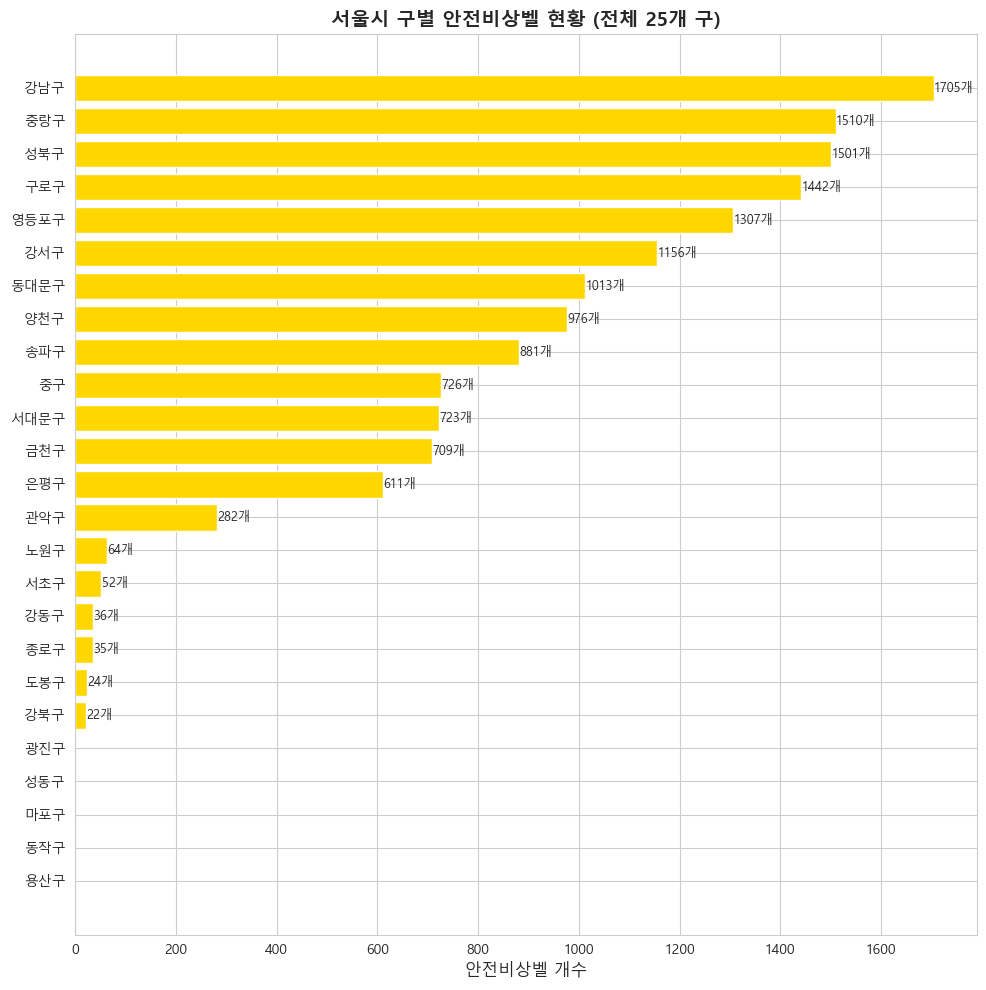


총 안전비상벨: 23273개
설치된 구: 20개
미설치 구: 5개


In [14]:
# 서울 25개 구 목록
seoul_districts = [
    '강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구',
    '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구',
    '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구',
    '종로구', '중구', '중랑구'
]

# 안전비상벨 구 추출
bell_df['region'] = bell_df['소재지지번주소'].str.extract(r'(?:서울특별시|서울시)?\s*(\S+구)')

# 구별 집계
bell_by_region = bell_df.groupby('region').size().reset_index(name='bell_count')
bell_by_region = bell_by_region.dropna()

print(f"안전비상벨이 있는 구: {len(bell_by_region)}개")
print(f"서울시 전체 구: {len(seoul_districts)}개")

# 누락된 구 확인
extracted = set(bell_by_region['region'].tolist())
missing = set(seoul_districts) - extracted

print(f"\n안전비상벨이 없는 구 ({len(missing)}개):")
print(missing)

# 25개 구 모두 포함하도록 데이터프레임 생성
all_districts_df = pd.DataFrame({'region': seoul_districts})
bell_by_region_full = all_districts_df.merge(bell_by_region, on='region', how='left').fillna(0)
bell_by_region_full['bell_count'] = bell_by_region_full['bell_count'].astype(int)

print("\n=== 전체 25개 구 안전비상벨 현황 ===")
print(bell_by_region_full.sort_values('bell_count', ascending=False))

# 시각화
plt.figure(figsize=(10, 10))

bell_sorted = bell_by_region_full.sort_values('bell_count', ascending=False)
colors = ['gold' if x > 0 else 'lightgray' for x in bell_sorted['bell_count']]
plt.barh(bell_sorted['region'], bell_sorted['bell_count'], color=colors)
plt.xlabel('안전비상벨 개수', fontsize=12)
plt.title('서울시 구별 안전비상벨 현황 (전체 25개 구)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# 값 표시
for idx, row in bell_sorted.iterrows():
    if row['bell_count'] > 0:
        plt.text(row['bell_count'] + 0.3, row['region'], f"{int(row['bell_count'])}개", 
                 va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 통계
print(f"\n총 안전비상벨: {len(bell_df)}개")
print(f"설치된 구: {len(extracted)}개")
print(f"미설치 구: {len(missing)}개")


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


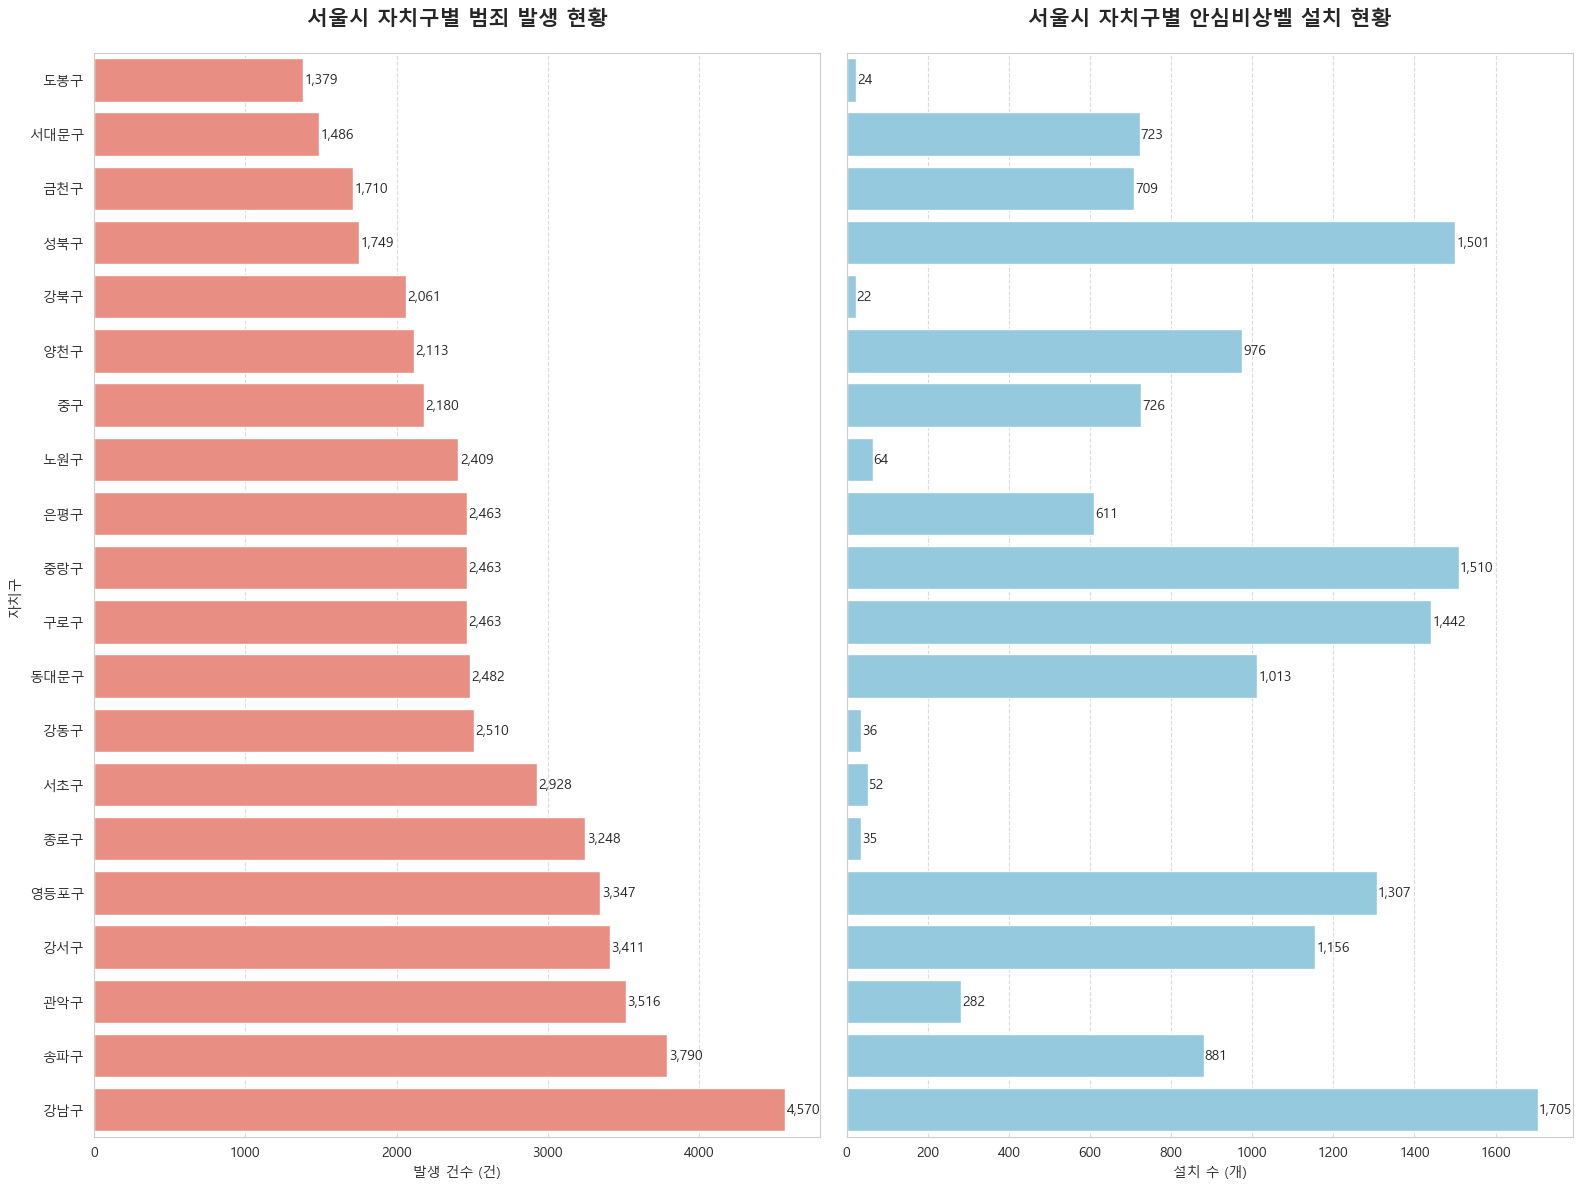

KeyError: '비상벨개수'

In [26]:
# 1. 데이터 로드 및 전처리
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황.csv', encoding='utf-8')
bell_df = pd.read_excel('../data/GraphDB_data/safety/12_04_09_E_안전비상벨위치정보.xlsx')

# 범죄 데이터 정리 (자치구별 발생 합계 추출)
col_name = '구분' if '구분' in crime_df.columns else '자치구별(2)'
# 4번째 컬럼이 보통 전체 발생 건수(합계)입니다.
val_col = '소계' if '소계' in crime_df.columns else crime_df.columns[3] 

crime_data = crime_df.copy()
crime_data['region'] = crime_data[col_name]
crime_data['범죄건수'] = pd.to_numeric(crime_data[val_col], errors='coerce')
crime_analysis = crime_data[~crime_data['region'].isin(['소계', '합계', '자치구별(2)', '자치구별(1)'])].dropna(subset=['범죄건수'])
crime_analysis = crime_analysis[['region', '범죄건수']].groupby('region').sum().reset_index()

# 비상벨 데이터 정리 (구별 설치 개수)
bell_df['region'] = bell_df['소재지지번주소'].str.extract(r'(\S+구)')
bell_count = bell_df.groupby('region').size().reset_index(name='비상벨개수')

# 데이터 합치기
df_plot = pd.merge(crime_analysis, bell_count, on='region').sort_values('범죄건수', ascending=True)

# 2. 시각화 (가로 막대그래프로 가독성 극대화)
fig, axes = plt.subplots(1, 2, figsize=(16, 12), sharey=True)

# 왼쪽 그래프: 범죄 발생 현황
sns.barplot(data=df_plot, x='범죄건수', y='region', ax=axes[0], color='salmon')
axes[0].set_title('서울시 자치구별 범죄 발생 현황', fontsize=15, fontweight='bold', pad=20)
axes[0].set_xlabel('발생 건수 (건)')
axes[0].set_ylabel('자치구')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# 오른쪽 그래프: 비상벨 설치 현황
sns.barplot(data=df_plot, x='비상벨개수', y='region', ax=axes[1], color='skyblue')
axes[1].set_title('서울시 자치구별 안심비상벨 설치 현황', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xlabel('설치 수 (개)')
axes[1].set_ylabel('')  # Y축 레이블 생략 (왼쪽과 공유)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# 막대 끝에 값 표시
for i, val in enumerate(df_plot['범죄건수']):
    axes[0].text(val + 10, i, f'{int(val):,}', va='center', fontsize=10)
for i, val in enumerate(df_plot['비상벨개수']):
    axes[1].text(val + 2, i, f'{int(val):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

correlation = df_cctv_plot['비상벨개수'].corr(df_cctv_plot['범죄건수'])
print(f"\n[분석 결과] 비상벨개수와 범죄 발생 건수의 상관계수: {correlation:.4f}")


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


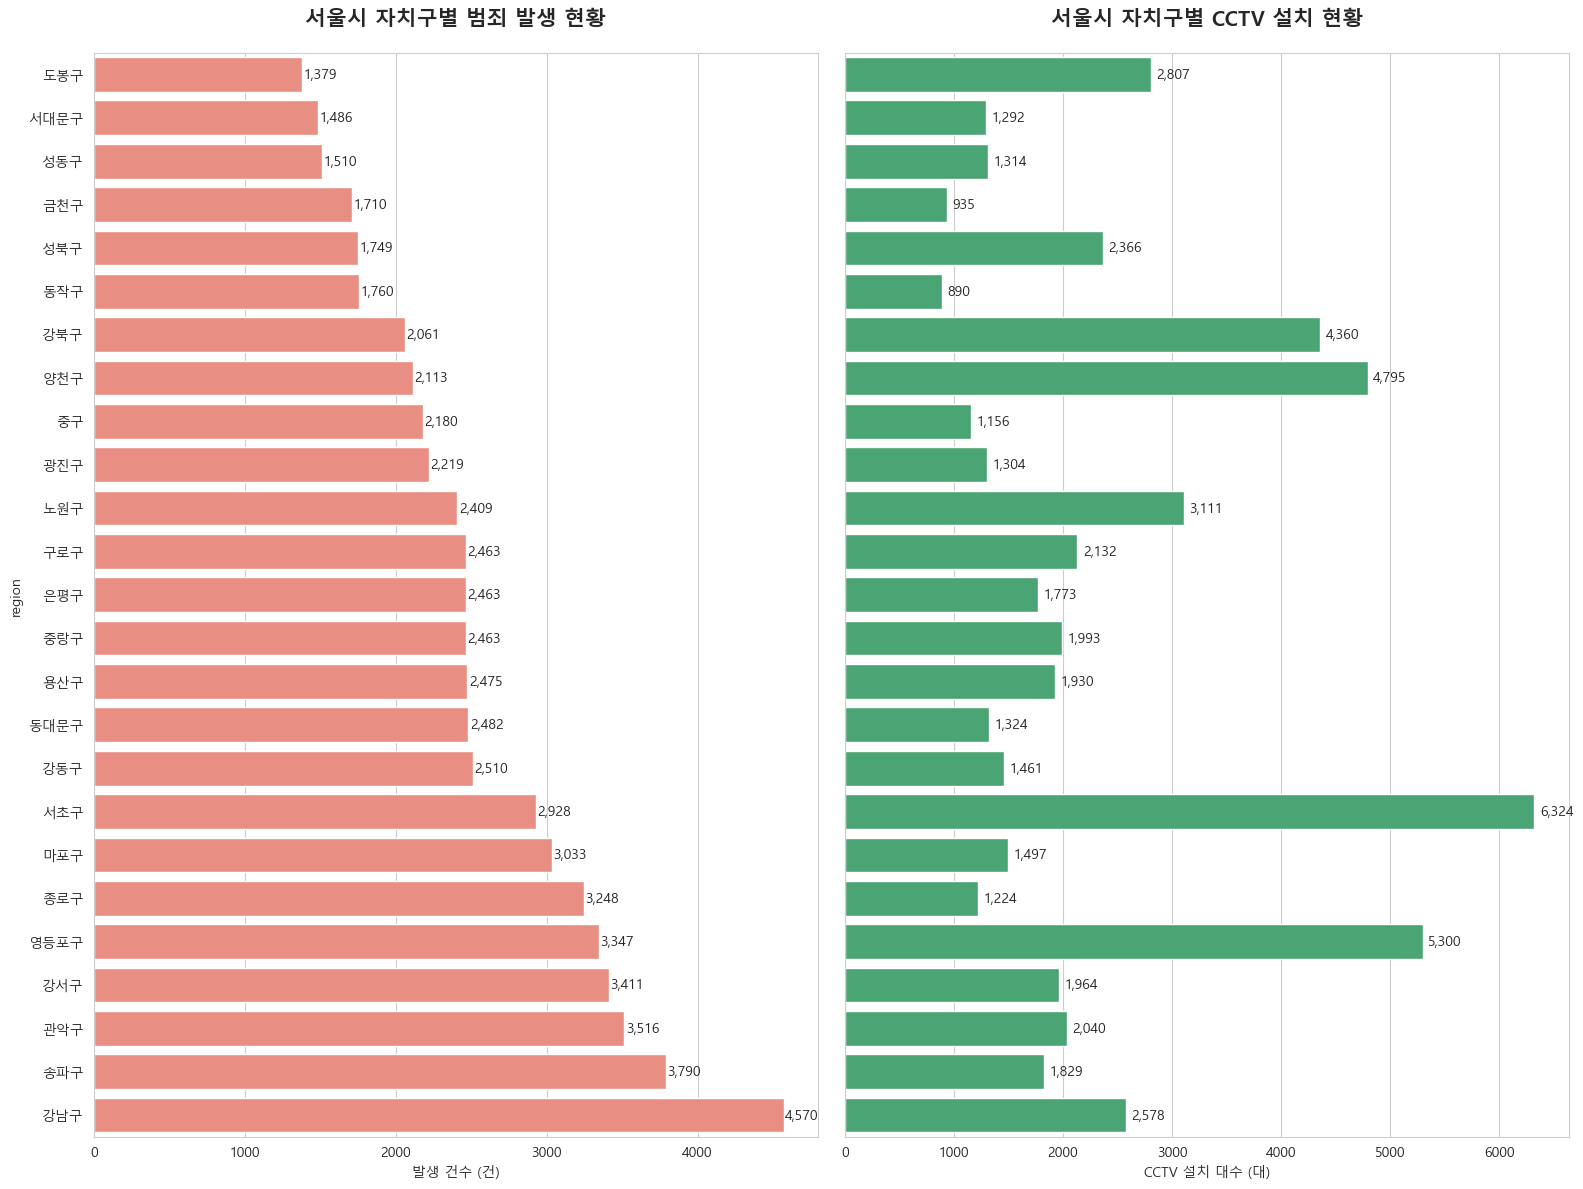


[분석 결과] CCTV 대수와 범죄 발생 건수의 상관계수: 0.1719


In [ ]:

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 (수정된 경로)
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황.csv', encoding='utf-8')
cctv_df = pd.read_excel('../data/GraphDB_data/safety/12_04_08_E_CCTV정보.xlsx')

# 2. 범죄 데이터 전처리
# 컬럼명 대응 (자치구별(2) 또는 구분)
crime_col = '자치구별(2)' if '자치구별(2)' in crime_df.columns else '구분'
val_col = '소계' if '소계' in crime_df.columns else crime_df.columns[3]

crime_data = crime_df.copy()
crime_data['region'] = crime_data[crime_col]
crime_data['범죄건수'] = pd.to_numeric(crime_data[val_col], errors='coerce')

# 실제 구 데이터만 필터링 (합계/소계 제외)
crime_analysis = crime_data[~crime_data['region'].isin(['소계', '합계', '자치구별(2)', '자치구별(1)'])].dropna(subset=['범죄건수'])
crime_analysis = crime_analysis[['region', '범죄건수']].groupby('region').sum().reset_index()

# 3. CCTV 데이터 전처리
# '관리기관명'에서 '강남구', '송파구' 등 자치구 이름 추출
cctv_df['region'] = cctv_df['관리기관명'].str.extract(r'(\S+구)')
cctv_count = cctv_df.groupby('region').size().reset_index(name='CCTV개수')

# 4. 데이터 병합 및 정렬
df_cctv_plot = pd.merge(crime_analysis, cctv_count, on='region').sort_values('범죄건수', ascending=True)

# 5. 시각화 (범죄 vs CCTV)
fig, axes = plt.subplots(1, 2, figsize=(16, 12), sharey=True)

# 왼쪽: 범죄 발생 현황
sns.barplot(data=df_cctv_plot, x='범죄건수', y='region', ax=axes[0], color='salmon')
axes[0].set_title('서울시 자치구별 범죄 발생 현황', fontsize=15, fontweight='bold', pad=20)
axes[0].set_xlabel('발생 건수 (건)')

# 오른쪽: CCTV 설치 현황
sns.barplot(data=df_cctv_plot, x='CCTV개수', y='region', ax=axes[1], color='mediumseagreen')
axes[1].set_title('서울시 자치구별 CCTV 설치 현황', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xlabel('CCTV 설치 대수 (대)')

# 막대 끝에 수치 표시
for i, val in enumerate(df_cctv_plot['범죄건수']):
    axes[0].text(val + 10, i, f'{int(val):,}', va='center', fontsize=10)
for i, val in enumerate(df_cctv_plot['CCTV개수']):
    axes[1].text(val + 50, i, f'{int(val):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 6. 상관계수 출력
correlation = df_cctv_plot['CCTV개수'].corr(df_cctv_plot['범죄건수'])
print(f"\n[분석 결과] CCTV 대수와 범죄 발생 건수의 상관계수: {correlation:.4f}")

c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


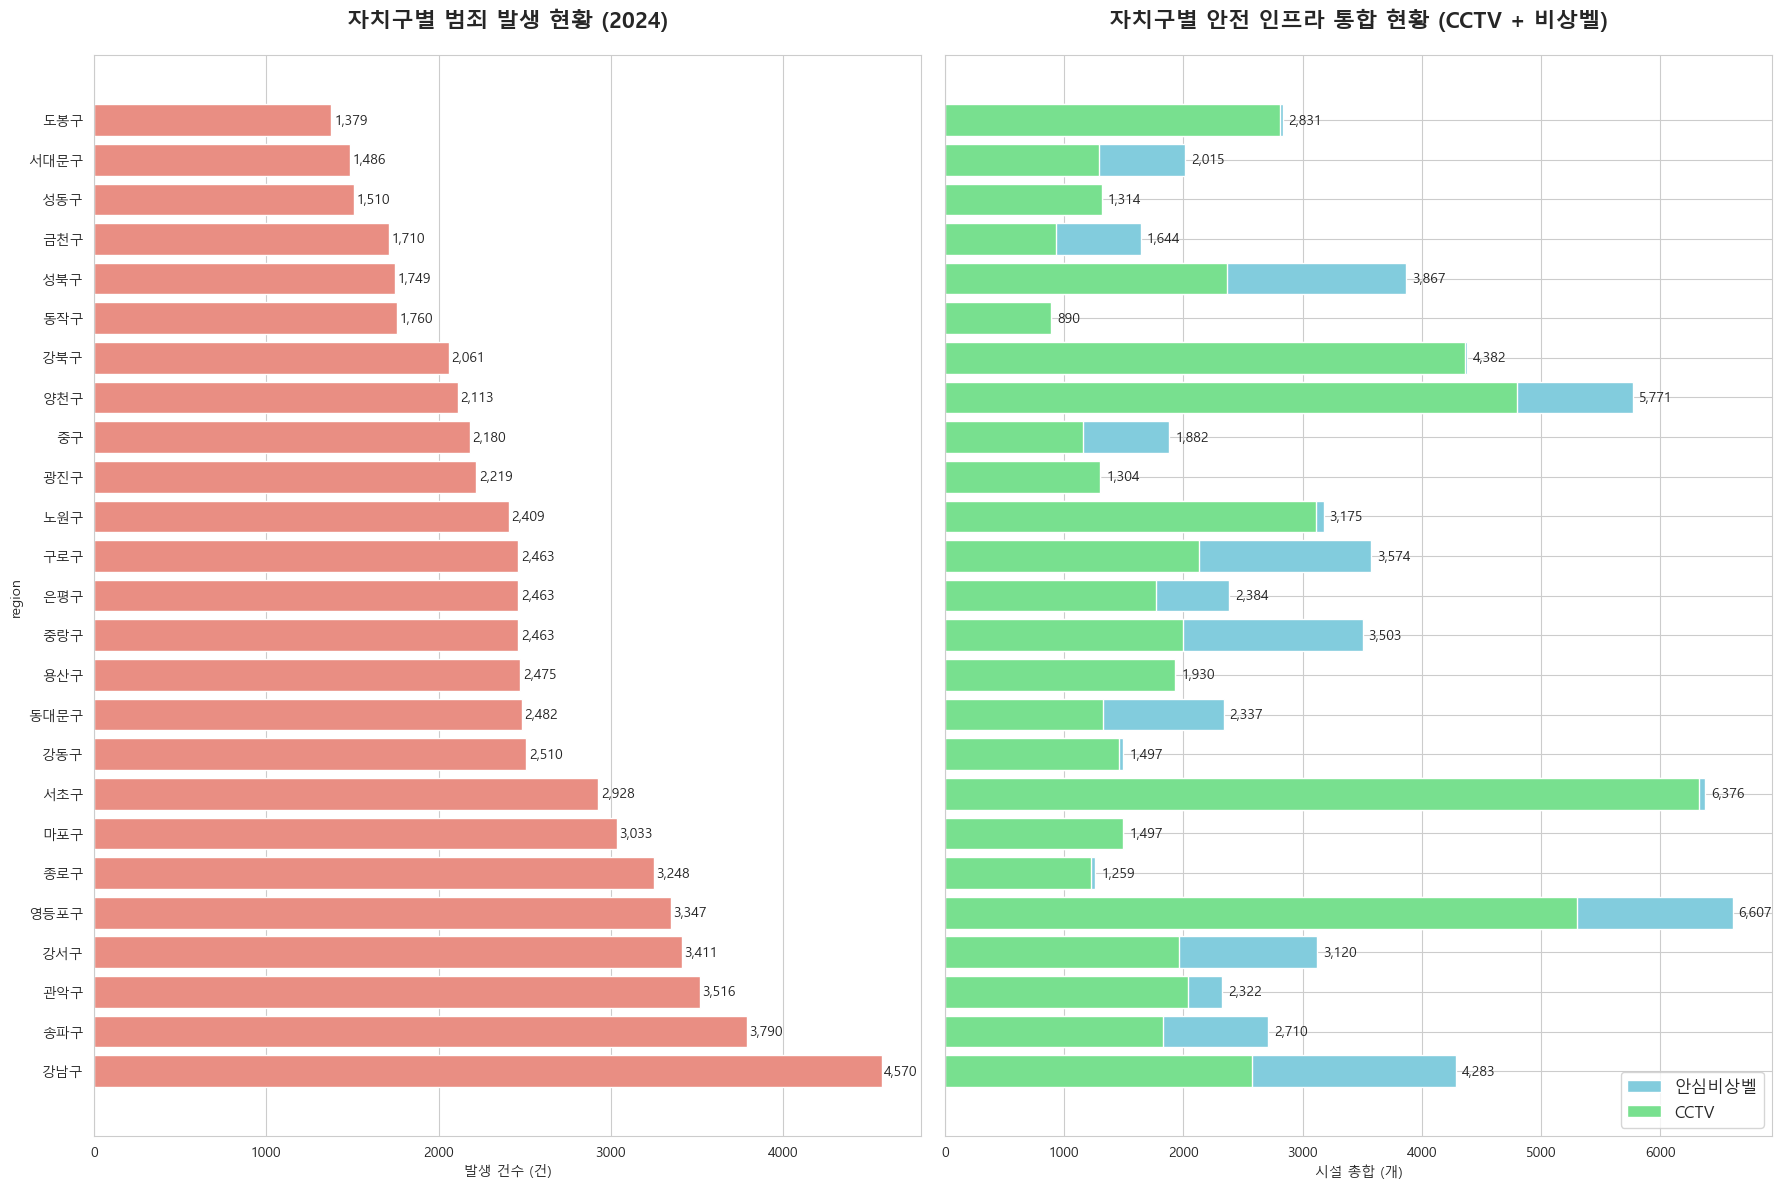


[분석 결과] 통합 안전 인프라(CCTV+비상벨)와 범죄 발생의 상관계수: 0.2690


In [23]:
# 1. 데이터 로드
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황.csv', encoding='utf-8')
cctv_df = pd.read_excel('../data/GraphDB_data/safety/12_04_08_E_CCTV정보.xlsx')
bell_df = pd.read_excel('../data/GraphDB_data/safety/12_04_09_E_안전비상벨위치정보.xlsx')

# 2. 범죄 데이터 전처리 (자치구별 합계 추출)
crime_col = '자치구별(2)' if '자치구별(2)' in crime_df.columns else '구분'
val_col = '소계' if '소계' in crime_df.columns else crime_df.columns[3]

crime_data = crime_df.copy()
crime_data['region'] = crime_data[crime_col]
crime_data['범죄건수'] = pd.to_numeric(crime_data[val_col], errors='coerce')
crime_analysis = crime_data[~crime_data['region'].isin(['소계', '합계', '자치구별(2)', '자치구별(1)'])].dropna(subset=['범죄건수'])
crime_analysis = crime_analysis[['region', '범죄건수']].groupby('region').sum().reset_index()

# 3. CCTV 데이터 전처리 (구별 설치 개수)
cctv_df['region'] = cctv_df['관리기관명'].str.extract(r'(\S+구)')
cctv_count = cctv_df.groupby('region').size().reset_index(name='CCTV개수')

# 4. 비상벨 데이터 전처리 (구별 설치 개수)
bell_df['region'] = bell_df['소재지지번주소'].str.extract(r'(\S+구)')
bell_count = bell_df.groupby('region').size().reset_index(name='비상벨개수')

# 5. 데이터 병합 (범죄 + CCTV + 비상벨)
df_final = pd.merge(crime_analysis, cctv_count, on='region', how='left')
df_final = pd.merge(df_final, bell_count, on='region', how='left').fillna(0)

# 두 인프라 합계 계산
df_final['안전시설합계'] = df_final['CCTV개수'] + df_final['비상벨개수']

# 범죄 발생이 적은 순서대로 정렬 (가독성 증대)
df_final = df_final.sort_values('범죄건수', ascending=True)

# 6. 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 12), sharey=True)

# [왼쪽 그래프] 범죄 발생 현황
sns.barplot(data=df_final, x='범죄건수', y='region', ax=axes[0], color='salmon')
axes[0].set_title('자치구별 범죄 발생 현황 (2024)', fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('발생 건수 (건)')

# [오른쪽 그래프] 안전 인프라 통합 현황 (CCTV + 비상벨)
# 누적 막대그래프를 통해 합계와 세부 비중 표현
axes[1].barh(df_final['region'], df_final['안전시설합계'], color='#82ccdd', label='안심비상벨') # 바탕: 전체 합계
axes[1].barh(df_final['region'], df_final['CCTV개수'], color='#78e08f', label='CCTV')     # 덮어쓰기: CCTV

axes[1].set_title('자치구별 안전 인프라 통합 현황 (CCTV + 비상벨)', fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel('시설 총합 (개)')
axes[1].legend(loc='lower right', fontsize=12)

# 수치 표시
for i, row in enumerate(df_final.itertuples()):
    axes[0].text(row.범죄건수 + 15, i, f'{int(row.범죄건수):,}', va='center', fontsize=10)
    axes[1].text(row.안전시설합계 + 50, i, f'{int(row.안전시설합계):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 7. 종합 상관관계 분석
total_corr = df_final['안전시설합계'].corr(df_final['범죄건수'])
print(f"\n[분석 결과] 통합 안전 인프라(CCTV+비상벨)와 범죄 발생의 상관계수: {total_corr:.4f}")

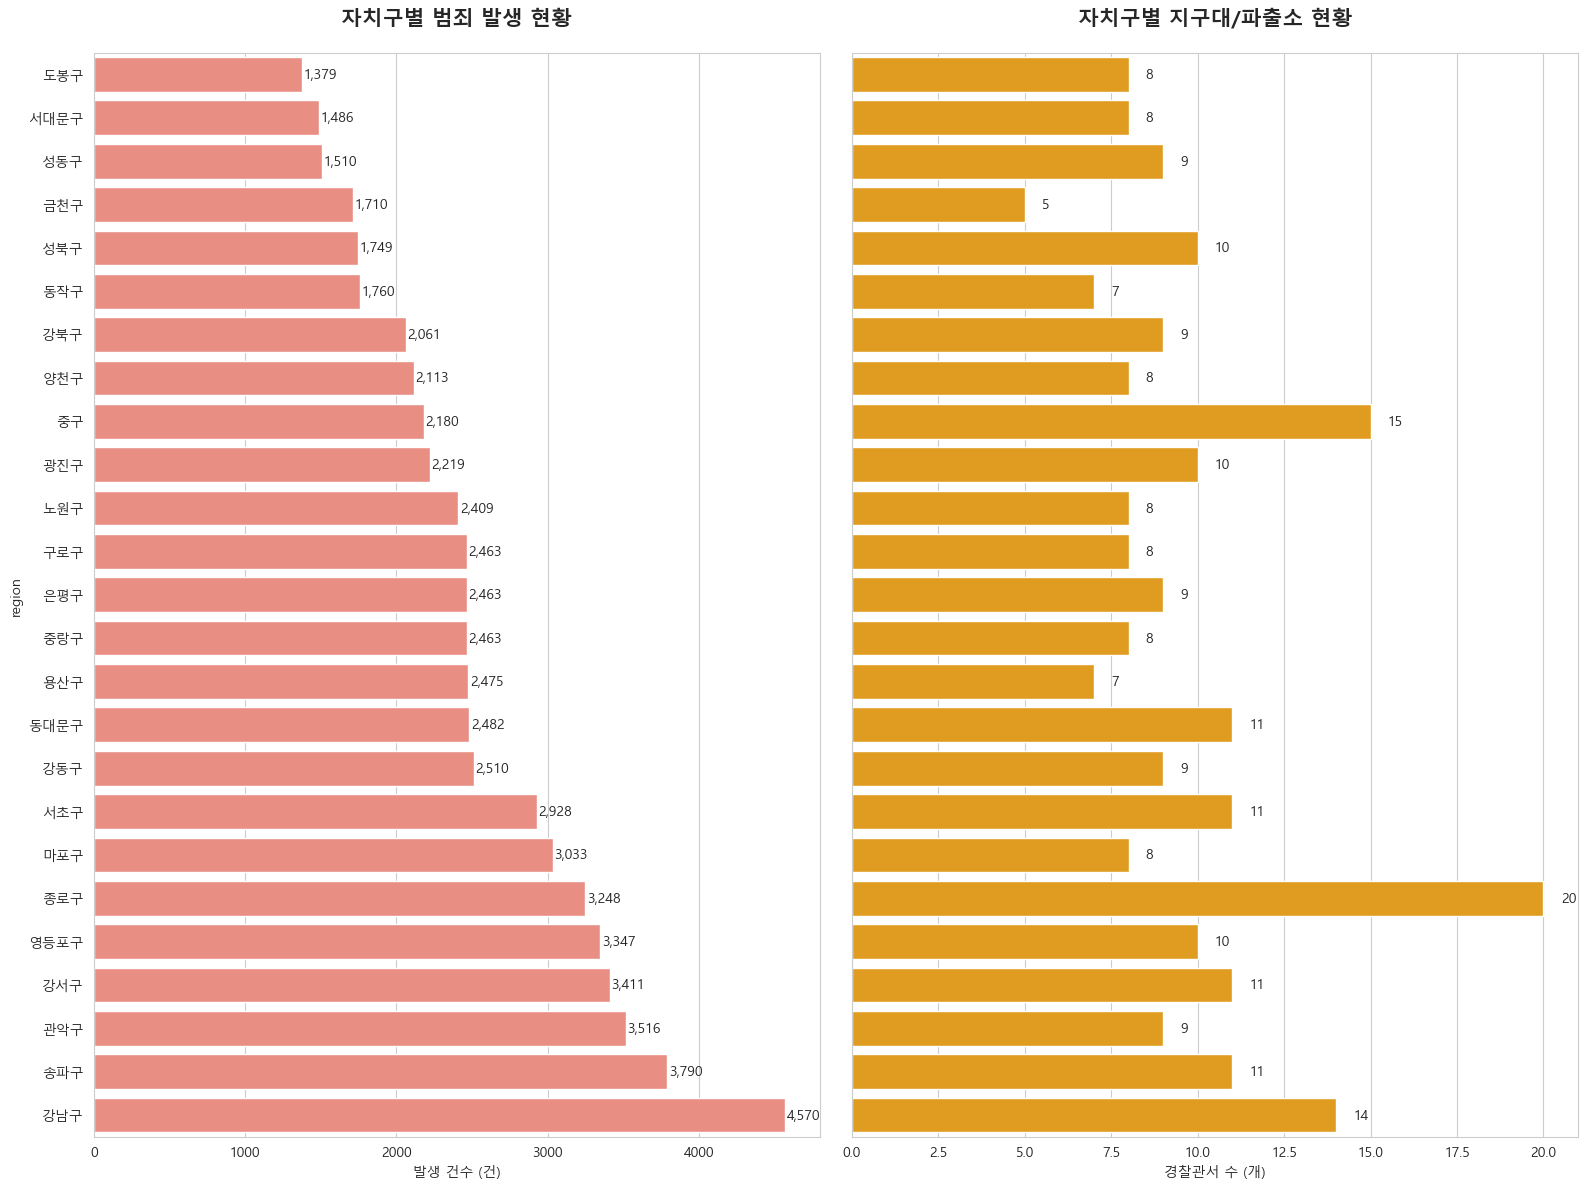


[분석 결과] 경찰관서 수와 범죄 발생 건수의 상관계수: 0.4870


In [27]:
# 1. 데이터 로드
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황.csv', encoding='utf-8')
# 경찰청 데이터는 인코딩이 cp949인 경우가 많으므로 예외 처리 포함
try:
    police_df = pd.read_csv('../data/GraphDB_data/office/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='utf-8')
except:
    police_df = pd.read_csv('../data/GraphDB_data/office/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='cp949')

# 2. 범죄 데이터 전처리
crime_col = '자치구별(2)' if '자치구별(2)' in crime_df.columns else '구분'
val_col = '소계' if '소계' in crime_df.columns else crime_df.columns[3]

crime_data = crime_df.copy()
crime_data['region'] = crime_data[crime_col]
crime_data['범죄건수'] = pd.to_numeric(crime_data[val_col], errors='coerce')
crime_analysis = crime_data[~crime_data['region'].isin(['소계', '합계', '자치구별(2)', '자치구별(1)'])].dropna(subset=['범죄건수'])
crime_analysis = crime_analysis[['region', '범죄건수']].groupby('region').sum().reset_index()

# 3. 지구대/파출소 데이터 전처리
# 서울특별시 데이터만 필터링
seoul_police = police_df[police_df['시도청'] == '서울청'].copy()
# 주소에서 자치구(..구) 추출
seoul_police['region'] = seoul_police['주소'].str.extract(r'(\S+구)')
police_count = seoul_police.groupby('region').size().reset_index(name='경찰관서수')

# 4. 데이터 병합
df_police_plot = pd.merge(crime_analysis, police_count, on='region').sort_values('범죄건수', ascending=True)

# 5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 12), sharey=True)

# 왼쪽: 범죄 발생 현황
sns.barplot(data=df_police_plot, x='범죄건수', y='region', ax=axes[0], color='salmon')
axes[0].set_title('자치구별 범죄 발생 현황', fontsize=15, fontweight='bold', pad=20)
axes[0].set_xlabel('발생 건수 (건)')

# 오른쪽: 지구대/파출소 현황
sns.barplot(data=df_police_plot, x='경찰관서수', y='region', ax=axes[1], color='orange')
axes[1].set_title('자치구별 지구대/파출소 현황', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xlabel('경찰관서 수 (개)')

# 수치 표시
for i, val in enumerate(df_police_plot['범죄건수']):
    axes[0].text(val + 10, i, f'{int(val):,}', va='center', fontsize=10)
for i, val in enumerate(df_police_plot['경찰관서수']):
    axes[1].text(val + 0.5, i, f'{int(val):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 6. 상관계수 출력
corr_police = df_police_plot['경찰관서수'].corr(df_police_plot['범죄건수'])
print(f"\n[분석 결과] 경찰관서 수와 범죄 발생 건수의 상관계수: {corr_police:.4f}")

C:\Users\Playdata\AppData\Local\Temp\ipykernel_37992\2482047140.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all_25, x='취약지수', y='region', palette='RdYlBu_r')


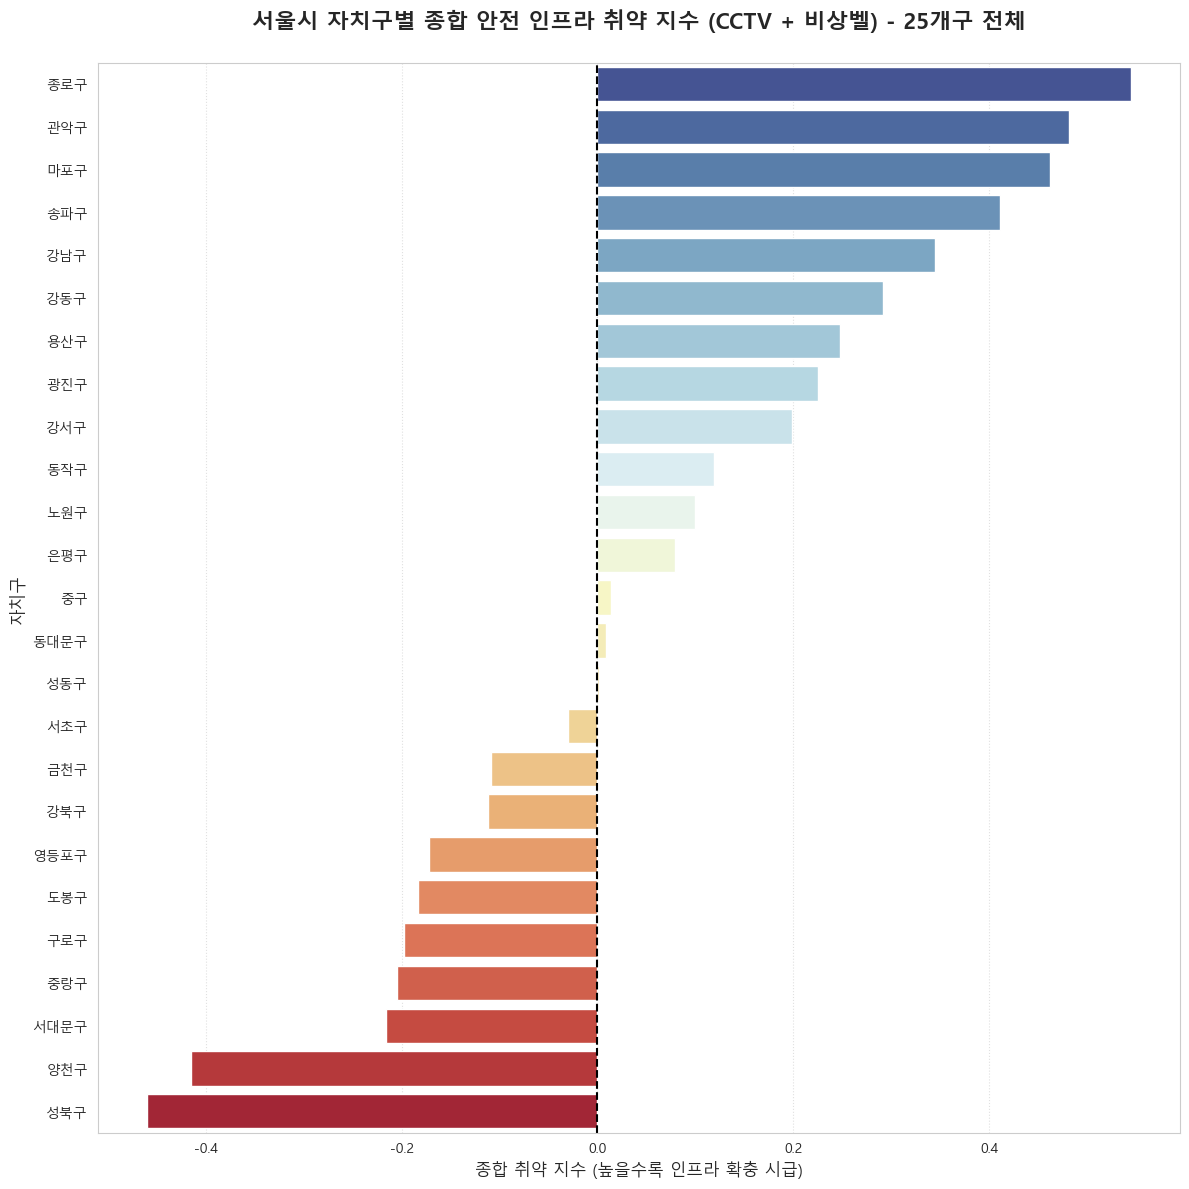

=== 범죄 대비 종합 안전 인프라가 취약한 상위 5개 자치구 ===
   region    범죄건수   비상벨개수  CCTV개수    종합취약지수
4     관악구  3516.0   282.0    2040  0.455132
12    마포구  3033.0     0.0    1497  0.414431
17    송파구  3790.0   881.0    1829  0.392390
0     강남구  4570.0  1705.0    2578  0.363121
20    용산구  2475.0     0.0    1930  0.235226


In [30]:
# 1. 데이터 로드 및 각 인프라별 집계 (사전 전처리)
# 범죄 데이터 (25개 구 기준점)
crime_col = '자치구별(2)' if '자치구별(2)' in crime_df.columns else '구분'
val_col = '소계' if '소계' in crime_df.columns else crime_df.columns[3]
crime_analysis = crime_df[~crime_df[crime_col].isin(['소계', '합계', '자치구별(2)', '자치구별(1)'])].copy()
crime_analysis['region'] = crime_analysis[crime_col]
crime_analysis['범죄건수'] = pd.to_numeric(crime_analysis[val_col], errors='coerce')
crime_base = crime_analysis[['region', '범죄건수']].groupby('region').sum().reset_index()

# CCTV 데이터
cctv_df['region'] = cctv_df['관리기관명'].str.extract(r'(\S+구)')
cctv_count = cctv_df.groupby('region').size().reset_index(name='CCTV개수')

# 비상벨 데이터
bell_df['region'] = bell_df['소재지지번주소'].str.extract(r'(\S+구)')
bell_count = bell_df.groupby('region').size().reset_index(name='비상벨개수')

# 2. 데이터 병합 (how='left'를 사용하여 25개 구 유지)
df_all_25 = pd.merge(crime_base, cctv_count, on='region', how='left')
df_all_25 = pd.merge(df_all_25, bell_count, on='region', how='left')

# 데이터가 없는 구는 0으로 채우기
df_all_25 = df_all_25.fillna(0)

# 3. 정규화 및 지수 산출
scaler = MinMaxScaler()
df_all_25['범죄_정규화'] = scaler.fit_transform(df_all_25[['범죄건수']])
df_all_25['비상벨_정규화'] = scaler.fit_transform(df_all_25[['비상벨개수']])
df_all_25['CCTV_정규화'] = scaler.fit_transform(df_all_25[['CCTV개수']])

# 인프라 종합 (CCTV + 비상벨)
df_all_25['인프라_합산'] = (df_all_25['CCTV_정규화'] + df_all_25['비상벨_정규화']) / 2
df_all_25['취약지수'] = df_all_25['범죄_정규화'] - df_all_25['인프라_합산']

# 정렬
df_all_25 = df_all_25.sort_values('취약지수', ascending=False)

# 4. 시각화
plt.figure(figsize=(12, 12))
sns.barplot(data=df_all_25, x='취약지수', y='region', palette='RdYlBu_r')

plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('서울시 자치구별 종합 안전 인프라 취약 지수 (CCTV + 비상벨) - 25개구 전체', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('종합 취약 지수 (높을수록 인프라 확충 시급)', fontsize=12)
plt.ylabel('자치구', fontsize=12)

plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. 최종 결과 출력
print("=== 범죄 대비 종합 안전 인프라가 취약한 상위 5개 자치구 ===")
result_cols = ['region', '범죄건수', '비상벨개수', 'CCTV개수', '종합취약지수']
print(df_total[result_cols].head(5))

C:\Users\Playdata\AppData\Local\Temp\ipykernel_37992\1367705209.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_total, x='종합취약지수', y='region', palette='RdYlBu_r')


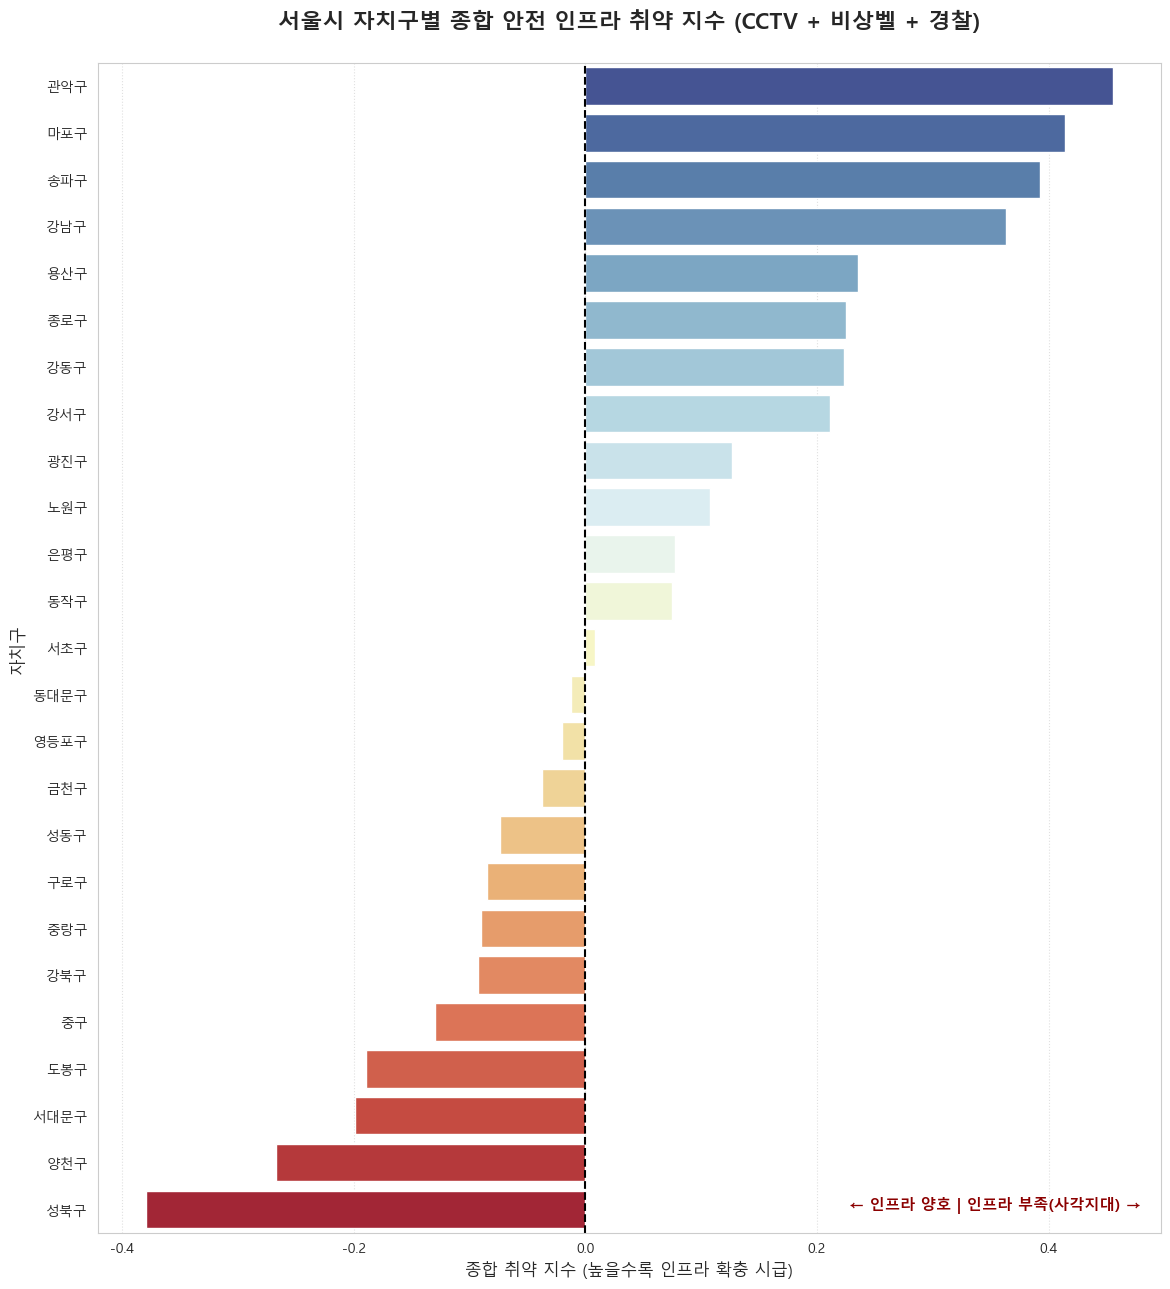

=== 범죄 대비 종합 안전 인프라가 취약한 상위 5개 자치구 ===
   region    범죄건수   비상벨개수  CCTV개수  경찰관서수    종합취약지수
4     관악구  3516.0   282.0    2040      9  0.455132
12    마포구  3033.0     0.0    1497      8  0.414431
17    송파구  3790.0   881.0    1829     11  0.392390
0     강남구  4570.0  1705.0    2578     14  0.363121
20    용산구  2475.0     0.0    1930      7  0.235226


In [28]:
# 1. 추가 데이터 로드 (경찰관서) 및 전처리
try:
    police_df = pd.read_csv('../data/GraphDB_data/office/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='utf-8')
except:
    police_df = pd.read_csv('../data/GraphDB_data/office/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='cp949')

# 서울청 데이터만 필터링 및 구 추출
seoul_police = police_df[police_df['시도청'] == '서울청'].copy()
seoul_police['region'] = seoul_police['주소'].str.extract(r'(\S+구)')
police_count = seoul_police.groupby('region').size().reset_index(name='경찰관서수')

# 모든 데이터 병합 (Crime + CCTV + Bell + Police)
df_total = pd.merge(crime_analysis, cctv_count, on='region', how='left')
df_total = pd.merge(df_total, bell_count, on='region', how='left')
df_total = pd.merge(df_total, police_count, on='region', how='left').fillna(0)

# 2. 데이터 정규화 (Min-Max Scaling)
scaler = MinMaxScaler()

df_total['범죄_정규화'] = scaler.fit_transform(df_total[['범죄건수']])
df_total['비상벨_정규화'] = scaler.fit_transform(df_total[['비상벨개수']])
df_total['CCTV_정규화'] = scaler.fit_transform(df_total[['CCTV개수']])
df_total['경찰_정규화'] = scaler.fit_transform(df_total[['경찰관서수']])

# 3. 종합 지수 산출 (3가지 인프라 평균)
# 인프라 점수 = (비상벨 + CCTV + 경찰관서) / 3
df_total['인프라_종합'] = (df_total['비상벨_정규화'] + df_total['CCTV_정규화'] + df_total['경찰_정규화']) / 3

# 최종 취약 지수 = 범죄 발생량 - 인프라 종합 점수
# (+): 범죄는 많은데 전체적인 인프라 부족 / (-): 범죄 대비 전반적 인프라 양호
df_total['종합취약지수'] = df_total['범죄_정규화'] - df_total['인프라_종합']

# 지수가 높은 순(취약한 순)으로 정렬
df_total = df_total.sort_values('종합취약지수', ascending=False)

# 4. 결과 시각화
plt.figure(figsize=(12, 13))
sns.barplot(data=df_total, x='종합취약지수', y='region', palette='RdYlBu_r')

plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('서울시 자치구별 종합 안전 인프라 취약 지수 (CCTV + 비상벨 + 경찰)', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('종합 취약 지수 (높을수록 인프라 확충 시급)', fontsize=12)
plt.ylabel('자치구', fontsize=12)

plt.text(df_total['종합취약지수'].max()*0.5, len(df_total)-1, '← 인프라 양호 | 인프라 부족(사각지대) →', 
         fontsize=11, color='darkred', fontweight='bold')

plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. 최종 결과 출력
print("=== 범죄 대비 종합 안전 인프라가 취약한 상위 5개 자치구 ===")
result_cols = ['region', '범죄건수', '비상벨개수', 'CCTV개수', '경찰관서수', '종합취약지수']
print(df_total[result_cols].head(5))

# 안전 온도 지표

## 범죄 데이터 로드 및 수치형 변환

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. 데이터 로드
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황.csv', encoding='utf-8')

# 2. 위치 기반 컬럼 매핑 (서울시 범죄 통계 표준 위치)
# 1번 인덱스: 자치구명, 4번: 살인(발생), 6번: 강도(발생), 8번: 강간강제추행(발생), 10번: 절도(발생), 12번: 폭력(발생)
col_mapping = {
    crime_df.columns[1]: '자치구',
    crime_df.columns[4]: '살인',
    crime_df.columns[6]: '강도',
    crime_df.columns[8]: '강간·강제추행',
    crime_df.columns[10]: '절도',
    crime_df.columns[12]: '폭력'
}

# 필요한 컬럼만 추출하고 이름 변경
crime_data = crime_df[list(col_mapping.keys())].rename(columns=col_mapping)

# 3. 실제 데이터 행만 필터링 (헤더 성격의 데이터 및 '합계' 행 제외)
# 데이터가 시작되는 구청 이름(예: '종로구')부터 시작하도록 '합계' 등이 포함된 상단 행 제외
crime_data = crime_data[~crime_data['자치구'].isin(['자치구별(2)', '합계', '소계', '구분'])].copy()

# 4. 데이터 수치화 (문자열 '-' 등을 0으로 치환하고 숫자로 변환)
crime_cols = ['살인', '강도', '강간·강제추행', '절도', '폭력']
for col in crime_cols:
    crime_data[col] = pd.to_numeric(crime_data[col].astype(str).str.replace('-', '0'), errors='coerce').fillna(0)

print("📍위치 기반 데이터 전처리 완료")
crime_data.head()

📍위치 기반 데이터 전처리 완료


,자치구,살인,강도,강간·강제추행,절도,폭력
4,종로구,2,5,209,1183,1366
5,중구,5,5,177,1398,1370
6,용산구,10,4,267,1082,1959
7,성동구,5,3,114,966,1029
8,광진구,2,6,235,1320,1307


## 스케일링 전 가중치 설정 및 적용

In [75]:
# 6. 범죄별 가중치 설정 (원본 데이터에 바로 적용 버전)
# 숫자가 큰 '절도/폭력' 등의 영향을 조절하기 위해 가중치를 적용합니다.
weights = {
    '살인': 100.0,
    '강간·강제추행': 40.0,
    '강도': 20.0,
    '폭력': 3.0,
    '절도': 1.0 
}

# 가중치 적용 컬럼 생성
# crime_data (스케일링 전 원본 데이터)를 사용합니다.
weighted_raw_df = crime_data.copy()
weighted_cols = []

for col, weight in weights.items():
    new_col = f'{col}_가중점수'
    # 원본 건수에 가중치 곱하기
    weighted_raw_df[new_col] = weighted_raw_df[col] * weight
    weighted_cols.append(new_col)

print("🚨 원본 데이터 기반 범죄 유형별 가중치 적용 완료")
# 자치구명과 가중치가 적용된 결과값 확인
weighted_raw_df[['자치구'] + weighted_cols].head()

🚨 원본 데이터 기반 범죄 유형별 가중치 적용 완료


,자치구,살인_가중점수,강간·강제추행_가중점수,강도_가중점수,폭력_가중점수,절도_가중점수
4,종로구,200.0,8360.0,100.0,4098.0,1183.0
5,중구,500.0,7080.0,100.0,4110.0,1398.0
6,용산구,1000.0,10680.0,80.0,5877.0,1082.0
7,성동구,500.0,4560.0,60.0,3087.0,966.0
8,광진구,200.0,9400.0,120.0,3921.0,1320.0


## 스케일링

> - 첫 번째 방식을 쓰면: "건수는 적어도 강력 범죄가 빈번하게 발생하는 구"나 "다른 구에 비해 유독 특정 범죄가 튀는 구"를 찾아낼 수 있음
> - 두 번째 방식을 쓰면: "사람이 많이 모여서 단순 범죄 건수 자체가 많은 구(예: 강남구)"가 무조건 1등  

In [ ]:
# 5. MinMaxScaler 적용 (0~1로 먼저 만든 뒤 범위 조정)
scaler = MinMaxScaler()
crime_scaled = crime_data.copy()

# 0~1 사이로 스케일링 다운
crime_scaled[crime_cols] = scaler.fit_transform(crime_data[crime_cols])

# (옵션) 만약 0.5~1.5 사이의 절대값으로 분포시키고 싶다면 아래 식
# crime_scaled[crime_cols] = (crime_scaled[crime_cols] * (1.5 - 0.5)) + 0.5

print("⛓️‍💥 범죄별 스케일링 완료")
crime_scaled.head()

⛓️‍💥 범죄별 스케일링 완료


,자치구,살인,강도,강간·강제추행,절도,폭력
4,종로구,0.066667,0.294118,0.239859,0.225029,0.203958
5,중구,0.266667,0.294118,0.183422,0.351351,0.205574
6,용산구,0.600000,0.235294,0.342152,0.165687,0.443457
7,성동구,0.266667,0.176471,0.072310,0.097532,0.067851
8,광진구,0.066667,0.352941,0.285714,0.305523,0.180129


## 범죄별 가중치(Weight) 설정 및 적용
> - 살인 1.5, 강간·강제추행 1.3 일때 폭력, 절도에 점수 묻힐 가능성 큼

In [78]:
# 6. 범죄별 가중치 설정
# 살인/강도 같은 중범죄에 높은 가중치를 부여
weights = {
   '살인': 3.0,
    '강간·강제추행': 2.0,
    '강도': 1.8,
    '폭력': 1.0,
    '절도': 0.7 
}

# 가중치 적용 컬럼 생성
weighted_cols = []
for col, weight in weights.items():
    new_col = f'{col}_가중점수'
    crime_scaled[new_col] = crime_scaled[col] * weight
    weighted_cols.append(new_col)

print("🚨 범죄 유형별 가중치 적용 완료")
crime_scaled[['자치구'] + weighted_cols].head()

🚨 범죄 유형별 가중치 적용 완료


,자치구,살인_가중점수,강간·강제추행_가중점수,강도_가중점수,폭력_가중점수,절도_가중점수
4,종로구,0.2,0.479718,0.529412,0.203958,0.157521
5,중구,0.8,0.366843,0.529412,0.205574,0.245946
6,용산구,1.8,0.684303,0.423529,0.443457,0.115981
7,성동구,0.8,0.144621,0.317647,0.067851,0.068273
8,광진구,0.2,0.571429,0.635294,0.180129,0.213866


## 최종 범죄 위험 지수 산출 및 순위 확인 

C:\Users\Playdata\AppData\Local\Temp\ipykernel_37992\1689795214.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crime_final, x='최종_범죄위험점수', y='자치구', palette='Reds_r')


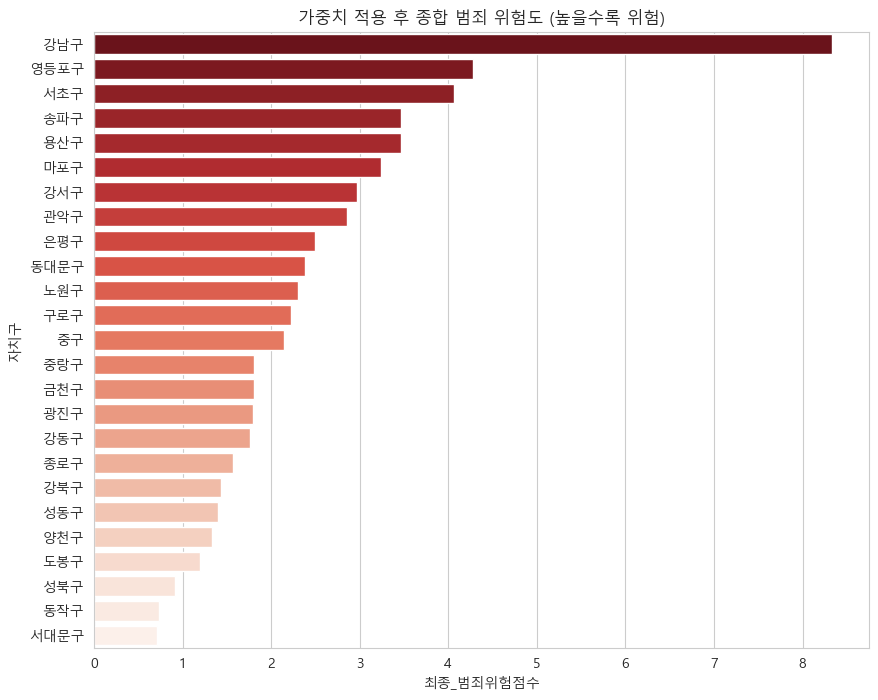

최종 위험도 상위 5개 지역:
     자치구  최종_범죄위험점수
26   강남구   8.333431
22  영등포구   4.277448
25   서초구   4.067656
27   송파구   3.471828
6    용산구   3.467271


In [79]:
# 7. 종합 위험도 합산
crime_scaled['최종_범죄위험점수'] = crime_scaled[weighted_cols].sum(axis=1)

# 위험도가 높은 순으로 정렬
crime_final = crime_scaled[['자치구', '최종_범죄위험점수']].sort_values('최종_범죄위험점수', ascending=False)

# 결과 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(data=crime_final, x='최종_범죄위험점수', y='자치구', palette='Reds_r')
plt.title('가중치 적용 후 종합 범죄 위험도 (높을수록 위험)')
plt.show()

print("최종 위험도 상위 5개 지역:")
print(crime_final.head(5))

## 안전 인프라와 결합

In [80]:
# 1. 범죄 데이터 컬럼명 확인 및 지정
# '최종_범죄위험도' 또는 '최종_범죄위험점수' 등 실제 있는 것을 찾습니다.
crime_score_col = '최종_범죄위험도' if '최종_범죄위험도' in crime_scaled.columns else '최종_범죄위험점수'
region_col = '구분' if '구분' in crime_scaled.columns else '자치구'

# 2. 인프라 데이터 준비 (앞선 전처리의 cctv_count, bell_count, police_count 사용)
# crime_scaled에서 필요한 열만 추출하여 병합 시작
df_final_safety = pd.merge(crime_scaled[[region_col, crime_score_col]], 
                            cctv_count, left_on=region_col, right_on='region', how='left')

# 이후 데이터들 병합 (region 컬럼이 생겼으므로 이를 기준으로 통합)
df_final_safety = pd.merge(df_final_safety, bell_count, on='region', how='left')
df_final_safety = pd.merge(df_final_safety, police_count, on='region', how='left').fillna(0)

# 분석 편의를 위해 '구분'으로 이름 통일
df_final_safety['구분'] = df_final_safety[region_col]
df_final_safety['위험도'] = df_final_safety[crime_score_col]

# 3. 데이터 정규화 (Min-Max Scaling)
# CCTV, 비상벨, 경찰관서 데이터만 0~1로 맞춤
scaler = MinMaxScaler()
infra_cols = ['CCTV개수', '비상벨개수', '경찰관서수']
df_final_safety[infra_cols] = scaler.fit_transform(df_final_safety[infra_cols])

# 4. 종합 인프라 점수 계산 (CCTV 50%, 경찰 30%, 비상벨 20%)
df_final_safety['종합_인프라점수'] = (
    df_final_safety['CCTV개수'] * 0.3 + 
    df_final_safety['경찰관서수'] * 0.5 + 
    df_final_safety['비상벨개수'] * 0.2
)

print("👮🏻 범죄 위험도 + 인프라 데이터 통합 완료!")
df_final_safety[['구분', '위험도', '종합_인프라점수']].head()

👮🏻 범죄 위험도 + 인프라 데이터 통합 완료!


,구분,위험도,종합_인프라점수
0,종로구,1.570608,0.522545
1,중구,2.147774,0.433180
2,용산구,3.467271,0.124083
3,성동구,1.398392,0.156742
4,광진구,1.800718,0.189523


## 안전 온도 산출

C:\Users\Playdata\AppData\Local\Temp\ipykernel_37992\282366623.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=safety_sorted, x='안전온도', y='구분', palette='RdYlBu')


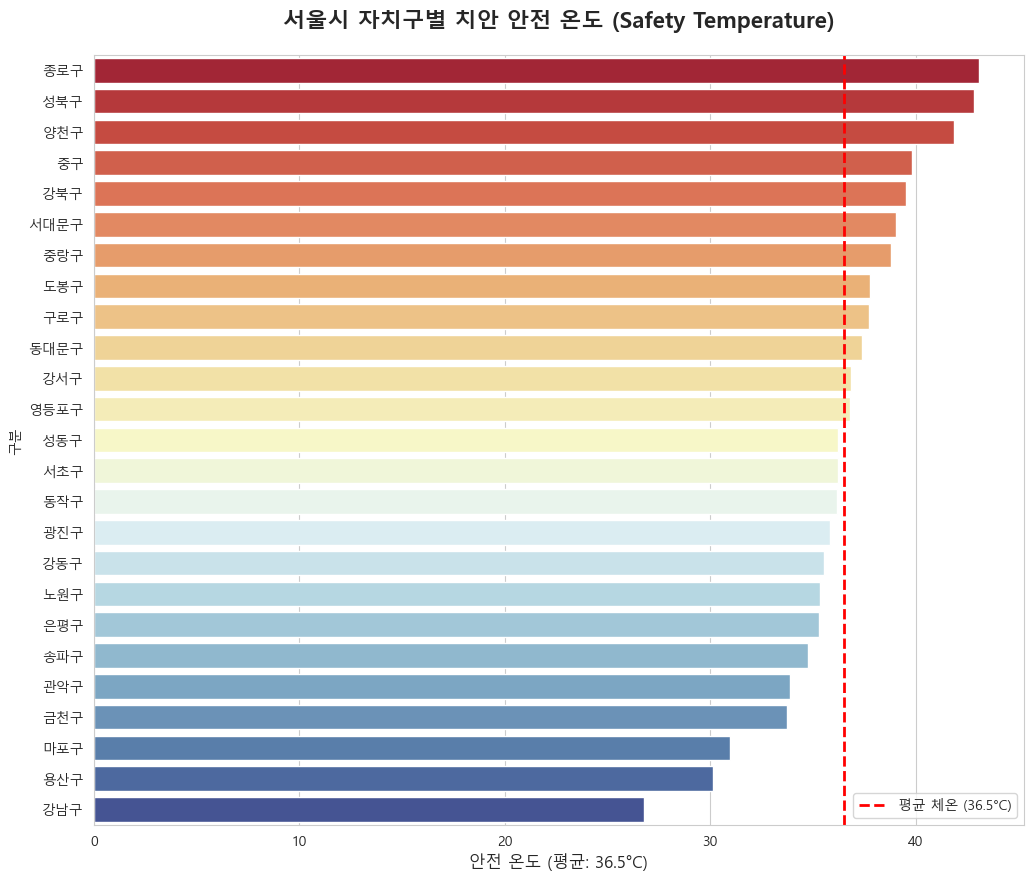

🌡️ 전체 자치구 평균 안전 온도: 36.5°C

=== [안전 온도 상위 3개 지역: 양호] ===
     구분       안전온도
0   종로구  43.103199
7   성북구  42.857863
14  양천구  41.877380

=== [안전 온도 하위 3개 지역: 위험] ===
     구분       안전온도
13  마포구  30.943711
2   용산구  30.157574
22  강남구  26.772114


In [81]:
# 1. 기초 안전지수 계산 (앞선 Cell 5에서 만든 데이터 사용)
# 지수 = 인프라점수 - 위험도_정규화
df_final_safety['위험도_정규화'] = scaler.fit_transform(df_final_safety[['위험도']])
df_final_safety['안전지수_raw'] = df_final_safety['종합_인프라점수'] - df_final_safety['위험도_정규화']

# 2. 평균을 36.5로 맞추는 알고리즘
# 일단 0점을 기준으로 편차(Deviation)를 구함
raw_mean = df_final_safety['안전지수_raw'].mean()
df_final_safety['편차'] = df_final_safety['안전지수_raw'] - raw_mean

# 3. 체온(36.5)에 편차를 더함 
# 이때 편차가 너무 작아 온도가 안 변하는 것을 막기 위해 '확대 계수(Scale Factor)'를 곱해줍니다.
# 10을 곱하면 평균에서 ±5~10도 정도 차이가 나게 됩니다.
scale_factor = 20  # 온도 차이를 더 뚜렷하게 보고 싶다면 이 숫자를 키우세요 (예: 20~30)
df_final_safety['안전온도'] = 36.5 + (df_final_safety['편차'] * scale_factor)

# 4. 온도 범위 제한 (너무 터무니없는 점수가 나오지 않게 0~100 사이로 클리핑)
df_final_safety['안전온도'] = df_final_safety['안전온도'].clip(0, 100)

# 정렬
safety_sorted = df_final_safety.sort_values('안전온도', ascending=False)

# 5. 시각화 (인간의 체온을 의미하는 온도계 느낌의 컬러)
plt.figure(figsize=(12, 10))
# 평균(36.5)보다 높으면 녹색/파랑(정상), 낮으면 노랑/빨강(저체온/위험)
norm = plt.Normalize(0, 100)
colors = plt.cm.RdYlBu(norm(safety_sorted['안전온도']))

sns.barplot(data=safety_sorted, x='안전온도', y='구분', palette='RdYlBu')

# 36.5도 기준선 표시
plt.axvline(36.5, color='red', linestyle='--', linewidth=2, label='평균 체온 (36.5°C)')
plt.title('서울시 자치구별 치안 안전 온도 (Safety Temperature)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('안전 온도 (평균: 36.5°C)', fontsize=12)
plt.legend()
plt.show()

# 최종 결과 확인
print(f"🌡️ 전체 자치구 평균 안전 온도: {df_final_safety['안전온도'].mean():.1f}°C")
print("\n=== [안전 온도 상위 3개 지역: 양호] ===")
print(safety_sorted[['구분', '안전온도']].head(3))
print("\n=== [안전 온도 하위 3개 지역: 위험] ===")
print(safety_sorted[['구분', '안전온도']].tail(3))